# EOS and MR

Coloring by ptot; max likelihood = 1.699936e-02; threshold = 0.001
../build/0.h5
../build/1.h5
../build/2.h5
../build/3.h5
../build/4.h5
../build/5.h5
../build/6.h5
../build/7.h5
../build/8.h5
../build/9.h5
../build/10.h5
../build/11.h5
../build/12.h5
../build/13.h5
../build/14.h5
../build/15.h5
../build/16.h5
../build/17.h5
../build/18.h5
../build/19.h5
../build/20.h5
../build/21.h5
../build/22.h5
../build/23.h5
../build/24.h5
../build/25.h5
../build/26.h5
../build/27.h5
../build/28.h5
../build/29.h5
../build/30.h5
../build/31.h5
../build/32.h5
../build/33.h5
../build/34.h5
../build/35.h5
../build/36.h5
../build/37.h5
../build/38.h5
../build/39.h5
../build/40.h5
../build/41.h5
../build/42.h5
../build/43.h5
../build/44.h5
../build/45.h5
../build/46.h5
../build/47.h5
../build/48.h5
../build/49.h5
number of plotted stable QM-core models: 59260
number of plotted twin-branch points: 11795
number of plotted non-twin points: 47465
number of plotted models: 59260
number of skipped incomplete 

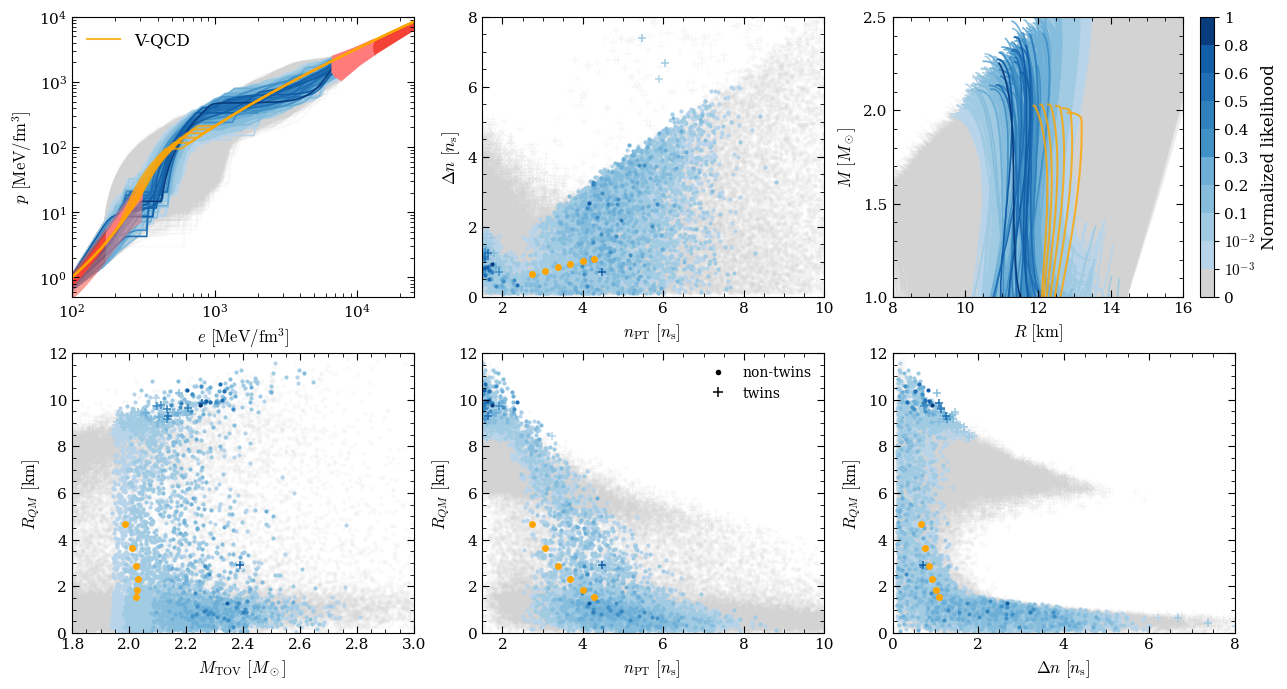

In [1]:
#!/usr/bin/env python3
"""
Plot EOS/TOV results from rank-wise HDF5 files.

Fixes relative to the original script:
  - Uses stab > 0, so disconnected stable branches labelled 2 are included.
  - Defines M_TOV as max(M) over all stable configurations.
  - Defines R_QM at the stable maximum-mass configuration.
  - Uses full posterior ptot for color normalization by default.
  - Avoids calling astro_constraints() twice for every EOS.
  - Skips missing/incomplete EOS groups instead of crashing.
  - Keeps compatibility with your plotting modules.
  - Uses + markers for twin-branch points and circle markers for non-twin points.

Run from the directory that can import modules/:
    python PTeos2_fixed_ptot.py

Adjust the parameters in the CONFIG block below as needed.
"""

import os
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator

from modules import plot_settings as ps
from modules import utils as u
from modules import functions as f


# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
INPUT_DIR = Path("../build")
FILE_PREFIX = ""
FILE_START_INDEX=0
NUM_FILES = 50
NEOS = 10000  # set to None to auto-detect numeric groups in each file
OUTPUT = "QMcoreEOSs.pdf"

# Use "ptot" for the full posterior. Alternatives: "pGW_xray", "pGW", "pM".
COLOR_BY = "ptot"

# If True, include only models with stable QM core at M_TOV.
ONLY_QM_CORE_AT_MTOV = True

# Marker convention for scatter-like data points.
# A twin model is defined here as a model whose stable M_TOV point lies on
# a stable branch with label > 1, i.e. usually stab == 2.
NON_TWIN_MARKER = "o"
TWIN_MARKER = "+"
NON_TWIN_MARKERSIZE = 3
TWIN_MARKERSIZE = 6
TWIN_MARKEREDGEWIDTH = 1.1

# Optional V-QCD overlay.
PLOT_VQCD = True
VQCD_FILE = Path("VQCD_data.h5")

# Figure settings.
NROW_FIG = 2
NCOL_FIG = 3
FIGSIZE = (15, 8)

# Axis limits.
RMIN, RMAX = 9, 15
MMIN, MMAX = 1, 2.5
DNMIN, DNMAX = 0, 8
NPTMIN, NPTMAX = 1.5, 10
RQM_MIN, RQM_MAX = 0, 12
MTOV_MIN, MTOV_MAX = 1.8, 3


# -----------------------------------------------------------------------------
# HDF5 helpers
# -----------------------------------------------------------------------------
def dataset_exists(h5, path):
    return path in h5


def read_scalar(h5, path, default=np.nan):
    if path not in h5:
        return default
    value = h5[path][()]
    arr = np.asarray(value)
    if arr.shape == ():
        return float(arr)
    if arr.size == 0:
        return default
    return float(arr.flat[0])


def read_array(h5, path):
    if path not in h5:
        raise KeyError(path)
    return h5[path][:]


def numeric_groups(h5):
    groups = []
    for key in h5.keys():
        if key.isdigit():
            groups.append(int(key))
    return sorted(groups)


def eos_indices(h5, neos):
    if neos is None:
        return numeric_groups(h5)
    return range(neos)


def likelihood_value(h5, base, mode="ptot"):
    params = f"{base}/params"

    if mode == "ptot":
        return read_scalar(h5, f"{params}/ptot", default=0.0)

    if mode == "pM":
        return read_scalar(h5, f"{params}/pM", default=0.0)

    if mode == "pGW":
        return read_scalar(h5, f"{params}/pGW", default=0.0)

    if mode == "pGW_xray":
        p_gw = read_scalar(h5, f"{params}/pGW", default=1.0)
        if f"{params}/pXray" in h5:
            px = np.asarray(h5[f"{params}/pXray"][:], dtype=float)
            # The code may zero-fill unused X-ray slots. Do not multiply zeros
            # from disabled or missing constraints into the diagnostic likelihood.
            positive = px[px > 0]
            p_x = float(np.prod(positive)) if positive.size else 1.0
        else:
            p_x = 1.0
        return p_gw * p_x

    raise ValueError(f"Unknown COLOR_BY mode: {mode}")


# -----------------------------------------------------------------------------
# Stability / branch helpers
# -----------------------------------------------------------------------------
def stable_mask(stab):
    """Return all stable configurations. Branch 1 and branch 2 are both stable."""
    return np.asarray(stab) > 0


def stable_branches_from_stab(stab):
    """Return index arrays for each positive stability label."""
    stab = np.asarray(stab)
    branches = []
    for label in sorted(np.unique(stab)):
        if label <= 0:
            continue
        idx = np.where(stab == label)[0]
        if idx.size >= 2:
            branches.append(idx)
    return branches


def stable_mtov_index(M, stab):
    """Index of maximum mass over all stable branches."""
    stable = stable_mask(stab)
    if not np.any(stable):
        return None
    stable_indices = np.where(stable)[0]
    return int(stable_indices[np.argmax(M[stable])])


def is_twin_branch_at_index(stab, idx):
    """Return True if the selected stable point belongs to a twin branch.

    The TOV code labels stable branches with positive integers. The first
    stable branch is label 1. A disconnected/twin branch is normally label 2.
    """
    if idx is None:
        return False
    return int(round(float(stab[idx]))) > 1


def marker_style_for_branch(stab, idx):
    if is_twin_branch_at_index(stab, idx):
        return {
            "marker": TWIN_MARKER,
            "markersize": TWIN_MARKERSIZE,
            "markeredgewidth": TWIN_MARKEREDGEWIDTH,
        }

    return {
        "marker": NON_TWIN_MARKER,
        "markersize": NON_TWIN_MARKERSIZE,
        "markeredgewidth": 0,
    }


def model_has_stable_qm_core_at_mtov(M, stab, Rqm, n_cent, npt):
    idx = stable_mtov_index(M, stab)
    if idx is None:
        return False, None

    has_core = (Rqm[idx] > 0.0) or (n_cent[idx] > npt)
    return bool(has_core), idx


# -----------------------------------------------------------------------------
# Figure setup
# -----------------------------------------------------------------------------
def setup_figure():
    fig, axs = ps.subplot_settings(
        NROW_FIG,
        NCOL_FIG,
        figsize=FIGSIZE,
        wspace=0.2,
        hspace=0.2,
        sharex=False,
        sharey=False,
        squeeze=False,
    )
    ps.configure_plot_style()
    cmap, bounds, norm, cbar = ps.colormap(fig, axs[0, 2], fraction=0.1, pad=0.05)

    axs[0, 0].set_xscale("log")
    axs[0, 0].set_yscale("log")
    axs[0, 0].minorticks_on()
    axs[0, 0].set_xlim(u.EMIN, u.EMAX)
    axs[0, 0].set_ylim(u.PMIN, u.PMAX)
    axs[0, 0].set_xlabel(r"$e$ $[\mathrm{MeV/fm}^{3}]$")
    axs[0, 0].set_ylabel(r"$p$ $[\mathrm{MeV/fm}^{3}]$")

    axs[0, 1].set_xlim(NPTMIN, NPTMAX)
    axs[0, 1].set_ylim(DNMIN, DNMAX)
    axs[0, 1].minorticks_on()
    axs[0, 1].set_xlabel(r"$n_{\mathrm{PT}}$ $[n_\mathrm{s}]$ ")
    axs[0, 1].set_ylabel(r"$\Delta n$ $[n_\mathrm{s}]$ ")

    axs[0, 2].set_xlim(RMIN, RMAX)
    axs[0, 2].set_ylim(MMIN, MMAX)
    axs[0, 2].minorticks_on()
    axs[0, 2].set_xlabel(r"$R$ $[\mathrm{km}]$")
    axs[0, 2].set_ylabel(r"$M$ $[M_\odot]$")
    axs[0, 2].set_xticks([8, 10, 12, 14, 16])

    axs[1, 0].set_xlim(MTOV_MIN, MTOV_MAX)
    axs[1, 0].set_ylim(RQM_MIN, RQM_MAX)
    axs[1, 0].minorticks_on()
    axs[1, 0].set_xlabel(r"$M_{\mathrm{TOV}}$ $[M_\odot]$ ")
    axs[1, 0].set_ylabel(r"$R_{QM}$ $[\mathrm{km}]$ ")

    axs[1, 1].set_xlim(NPTMIN, NPTMAX)
    axs[1, 1].set_ylim(RQM_MIN, RQM_MAX)
    axs[1, 1].minorticks_on()
    axs[1, 1].set_xlabel(r"$n_{\mathrm{PT}}$ $[n_\mathrm{s}]$ ")
    axs[1, 1].set_ylabel(r"$R_{QM}$ $[\mathrm{km}]$ ")

    axs[1, 2].set_xlim(DNMIN, DNMAX)
    axs[1, 2].set_ylim(RQM_MIN, RQM_MAX)
    axs[1, 2].minorticks_on()
    axs[1, 2].set_xlabel(r"$\Delta n$ $[n_\mathrm{s}]$ ")
    axs[1, 2].set_ylabel(r"$R_{QM}$ $[\mathrm{km}]$ ")

    apply_axis_ticks(axs)

    return fig, axs, cmap, bounds, norm, cbar


def apply_axis_ticks(axs):
    """Enable ticks on all four edges, but labels only on left and bottom."""
    for ax in axs.ravel():
        ax.tick_params(
            axis="both",
            which="major",
            direction="in",
            length=5,
            width=0.8,
            left=True,
            right=True,
            bottom=True,
            top=True,
            labelleft=True,
            labelright=False,
            labelbottom=True,
            labeltop=False,
        )
        ax.tick_params(
            axis="both",
            which="minor",
            direction="in",
            length=3,
            width=0.6,
            left=True,
            right=True,
            bottom=True,
            top=True,
            labelleft=False,
            labelright=False,
            labelbottom=False,
            labeltop=False,
        )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.xaxis.set_tick_params(labelbottom=True, labeltop=False)

    # Explicit y-axis numbers for the linear panels.
    axs[0, 1].set_yticks(np.arange(DNMIN, DNMAX + 0.1, 2))
    axs[0, 2].set_yticks(np.arange(MMIN, MMAX + 0.01, 0.5))
    axs[1, 0].set_yticks(np.arange(RQM_MIN, RQM_MAX + 0.1, 2))
    axs[1, 1].set_yticks(np.arange(RQM_MIN, RQM_MAX + 0.1, 2))
    axs[1, 2].set_yticks(np.arange(RQM_MIN, RQM_MAX + 0.1, 2))

    # Log EOS panel: labeled major ticks, unlabeled minor ticks.
    axs[0, 0].yaxis.set_major_locator(LogLocator(base=10.0, numticks=8))
    axs[0, 0].yaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=80)
    )
    axs[0, 0].yaxis.set_minor_formatter(plt.NullFormatter())


# -----------------------------------------------------------------------------
# Data scan and plotting
# -----------------------------------------------------------------------------
def compute_max_likelihood():
    max_like = 0.0
    for k in range(FILE_START_INDEX, FILE_START_INDEX + NUM_FILES):
        path = INPUT_DIR / f"{FILE_PREFIX}{k}.h5"
        if not path.exists():
            continue
        with h5py.File(path, "r") as h5:
            for i in eos_indices(h5, NEOS):
                base = f"/{i}"
                if f"{base}/params" not in h5:
                    continue
                val = likelihood_value(h5, base, COLOR_BY)
                if np.isfinite(val):
                    max_like = max(max_like, val)
    return max_like if max_like > 0 else 1.0


def plot_results():
    fig, axs, cmap, bounds, norm, cbar = setup_figure()
    max_like = compute_max_likelihood()
    threshold = bounds[1]

    print(f"Coloring by {COLOR_BY}; max likelihood = {max_like:.6e}; threshold = {threshold}")

    qm_count = 0
    twin_point_count = 0
    non_twin_point_count = 0
    plotted_count = 0
    skipped_count = 0

    for k in range(FILE_START_INDEX, FILE_START_INDEX + NUM_FILES):
        path = INPUT_DIR / f"{FILE_PREFIX}{k}.h5"
        print(path)
        if not path.exists():
            print(f"  missing, skipping")
            continue

        with h5py.File(path, "r") as h5:
            for i in eos_indices(h5, NEOS):
                base = f"/{i}"
                tov_path = f"{base}/TOV"
                eos_path = f"{base}/EOS"
                params_path = f"{base}/params"

                required = [
                    f"{tov_path}/M",
                    f"{tov_path}/R",
                    f"{tov_path}/Rqm",
                    f"{tov_path}/stab",
                    f"{tov_path}/n_cent",
                    f"{eos_path}/e",
                    f"{eos_path}/p",
                    f"{params_path}/dn",
                    f"{params_path}/nPTl",
                ]
                if any(req not in h5 for req in required):
                    skipped_count += 1
                    continue

                try:
                    M = read_array(h5, f"{tov_path}/M")
                    R = read_array(h5, f"{tov_path}/R")
                    Rqm = read_array(h5, f"{tov_path}/Rqm")
                    stab = read_array(h5, f"{tov_path}/stab")
                    n_cent = read_array(h5, f"{tov_path}/n_cent") / u.ns
                    e_data = read_array(h5, f"{eos_path}/e")
                    p_data = read_array(h5, f"{eos_path}/p")
                    dn = read_scalar(h5, f"{params_path}/dn")
                    npt = read_scalar(h5, f"{params_path}/nPTl") / u.ns
                except Exception:
                    skipped_count += 1
                    continue

                has_core, mtov_idx = model_has_stable_qm_core_at_mtov(M, stab, Rqm, n_cent, npt)
                if mtov_idx is None:
                    skipped_count += 1
                    continue
                if ONLY_QM_CORE_AT_MTOV and not has_core:
                    continue

                qm_count += int(has_core)
                Mtov = M[mtov_idx]
                Rqm_at_mtov = Rqm[mtov_idx]
                marker_style = marker_style_for_branch(stab, mtov_idx)
                is_twin = is_twin_branch_at_index(stab, mtov_idx)
                if is_twin:
                    twin_point_count += 1
                else:
                    non_twin_point_count += 1

                like = likelihood_value(h5, base, COLOR_BY)
                normalized = like / max_like if max_like > 0 else 0.0
                normalized = float(np.clip(normalized, 0.0, 1.0))

                if normalized < threshold:
                    color = "lightgrey"
                    alpha = 0.12
                    zorder = 0
                else:
                    color = cmap(norm(normalized))
                    alpha = 1.0
                    zorder = np.searchsorted(bounds, normalized) / max(1, len(bounds) - 1)

                axs[0, 0].plot(e_data, p_data, color=color, linewidth=1.2, zorder=zorder, alpha=alpha, rasterized=True)
                axs[0, 1].plot(npt, dn, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)
                axs[1, 0].plot(Mtov, Rqm_at_mtov, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)
                axs[1, 1].plot(npt, Rqm_at_mtov, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)
                axs[1, 2].plot(dn, Rqm_at_mtov, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)

                for branch in stable_branches_from_stab(stab):
                    axs[0, 2].plot(R[branch], M[branch], color=color, linewidth=1.2, zorder=zorder, alpha=alpha, rasterized=True)

                plotted_count += 1

    print("number of plotted stable QM-core models:", qm_count)
    print("number of plotted twin-branch points:", twin_point_count)
    print("number of plotted non-twin points:", non_twin_point_count)
    print("number of plotted models:", plotted_count)
    print("number of skipped incomplete models:", skipped_count)

    add_vqcd_overlay(axs)
    add_eos_constraint_regions(axs)

    add_marker_legend(axs)
    axs[0, 0].legend(loc="upper left", frameon=False, fontsize=12)
    plt.savefig(OUTPUT, dpi=300, bbox_inches="tight")
    print(f"Saved {OUTPUT}")


def add_marker_legend(axs):
    """Add a marker legend to the nPT-dn panel."""
    non_twin = plt.Line2D(
        [], [],
        color="black",
        marker=NON_TWIN_MARKER,
        linestyle="None",
        markersize=NON_TWIN_MARKERSIZE + 1,
        markeredgewidth=0,
        label="non-twins",
    )
    twin = plt.Line2D(
        [], [],
        color="black",
        marker=TWIN_MARKER,
        linestyle="None",
        markersize=TWIN_MARKERSIZE + 1,
        markeredgewidth=TWIN_MARKEREDGEWIDTH,
        label="twins",
    )
    axs[1, 1].legend(
        handles=[non_twin, twin],
        loc="upper right",
        frameon=False,
        fontsize=10,
    )


# -----------------------------------------------------------------------------
# Overlays
# -----------------------------------------------------------------------------
def add_vqcd_overlay(axs):
    if not PLOT_VQCD or not VQCD_FILE.exists():
        return

    gev3_to_invfm3 = 5.067730756672362 ** 3
    gev4_to_mevfm3 = 130149.0
    ns = 0.16

    with h5py.File(VQCD_FILE, "r") as h5:
        for j, key in enumerate(numeric_groups(h5)):
            base = f"/{key}"
            try:
                stab = read_array(h5, f"{base}/TOV/stab")
                stable = stable_mask(stab)
                if not np.any(stable):
                    continue
                R = read_array(h5, f"{base}/TOV/R")[stable]
                M = read_array(h5, f"{base}/TOV/M")[stable]
                Mtov=max(M)
                Rqm = read_array(h5, f"{base}/TOV/Rqm")[stable]
                RqmTOV=Rqm[-1]
                p_data = read_array(h5, f"{base}/EOS/p") * gev4_to_mevfm3
                e_data = read_array(h5, f"{base}/EOS/e") * gev4_to_mevfm3
                npt = read_scalar(h5, f"{base}/params/nPT") * gev3_to_invfm3 / ns
                dn = read_scalar(h5, f"{base}/params/Dn") * gev3_to_invfm3 / ns
            except Exception:
                continue

            label = "V-QCD" if j == 0 else None
            axs[0, 0].plot(e_data, p_data, color="orange", linewidth=1.5, zorder=2, alpha=0.8, label=label)
            axs[0, 1].plot(npt, dn, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)
            axs[0, 2].plot(R, M, color="orange", linewidth=1.5, zorder=2, alpha=0.8)
            axs[1, 0].plot(Mtov, RqmTOV, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)
            axs[1, 1].plot(npt, RqmTOV, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)
            axs[1, 2].plot(dn, RqmTOV, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)


def add_eos_constraint_regions(axs):
    axs[0, 0].fill(u.cs2boundary[:, 0], u.cs2boundary[:, 1], zorder=1.4, facecolor=u.cs2_color, edgecolor=None)
    axs[0, 0].fill(u.pQCDpoints[:, 0], u.pQCDpoints[:, 1], facecolor=u.pQCD_color, edgecolor=None, zorder=1.5)
    axs[0, 0].fill(u.boundary_ep_1ns_1s[:, 0], u.boundary_ep_1ns_1s[:, 1], facecolor=u.CET_1ns_color, edgecolor=None, zorder=1.5, alpha=1)
    axs[0, 0].fill(u.boundary_ep_2ns_1s[:, 0], u.boundary_ep_2ns_1s[:, 1], facecolor=u.CET_2ns_color, edgecolor=None, zorder=1.5, alpha=1)
    axs[0, 0].fill(u.boundary_ep_1ns_2s[:, 0], u.boundary_ep_1ns_2s[:, 1], facecolor=u.CET_1ns_color, edgecolor=None, zorder=1.5, alpha=0.5)
    axs[0, 0].fill(u.boundary_ep_2ns_2s[:, 0], u.boundary_ep_2ns_2s[:, 1], facecolor=u.CET_2ns_color, edgecolor=None, zorder=1.5, alpha=0.5)


if __name__ == "__main__":
    plot_results()

Coloring by ptot; max likelihood = 9.492045e-03; threshold = 0.001
../build2/0.h5
../build2/1.h5
../build2/2.h5
../build2/3.h5
../build2/4.h5
../build2/5.h5
../build2/6.h5
../build2/7.h5
../build2/8.h5
../build2/9.h5
../build2/10.h5
../build2/11.h5
../build2/12.h5
../build2/13.h5
../build2/14.h5
../build2/15.h5
../build2/16.h5
../build2/17.h5
../build2/18.h5
../build2/19.h5
../build2/20.h5
../build2/21.h5
../build2/22.h5
../build2/23.h5
../build2/24.h5
../build2/25.h5
../build2/26.h5
../build2/27.h5
../build2/28.h5
../build2/29.h5
../build2/30.h5
../build2/31.h5
../build2/32.h5
../build2/33.h5
../build2/34.h5
../build2/35.h5
../build2/36.h5
../build2/37.h5
../build2/38.h5
../build2/39.h5
../build2/40.h5
../build2/41.h5
../build2/42.h5
../build2/43.h5
../build2/44.h5
../build2/45.h5
../build2/46.h5
../build2/47.h5
../build2/48.h5
../build2/49.h5
number of plotted stable QM-core models: 102732
number of plotted twin-branch points: 15645
number of plotted non-twin points: 87087
number of 

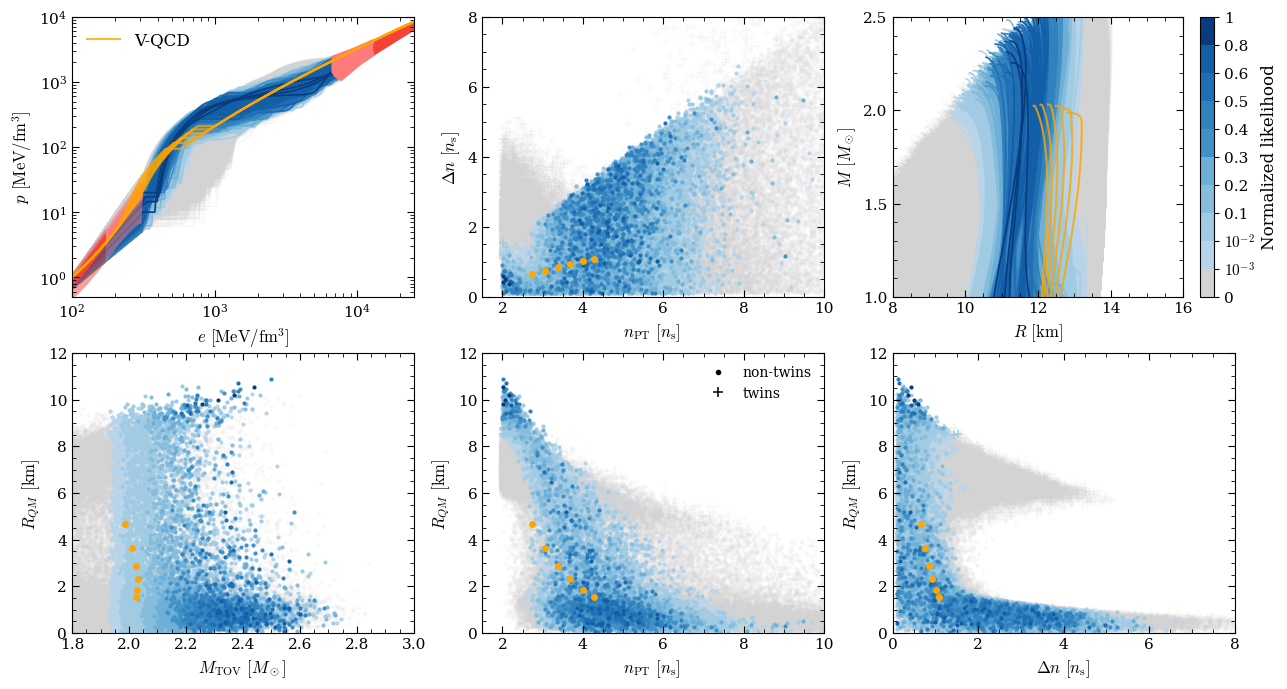

In [7]:
#!/usr/bin/env python3
"""
Plot EOS/TOV results from rank-wise HDF5 files.

Fixes relative to the original script:
  - Uses stab > 0, so disconnected stable branches labelled 2 are included.
  - Defines M_TOV as max(M) over all stable configurations.
  - Defines R_QM at the stable maximum-mass configuration.
  - Uses full posterior ptot for color normalization by default.
  - Avoids calling astro_constraints() twice for every EOS.
  - Skips missing/incomplete EOS groups instead of crashing.
  - Keeps compatibility with your plotting modules.
  - Uses + markers for twin-branch points and circle markers for non-twin points.

Run from the directory that can import modules/:
    python PTeos2_fixed_ptot.py

Adjust the parameters in the CONFIG block below as needed.
"""

import os
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator

from modules import plot_settings as ps
from modules import utils as u
from modules import functions as f


# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
INPUT_DIR = Path("../build2")
FILE_PREFIX = ""
FILE_START_INDEX=0
NUM_FILES = 50
NEOS = 10000  # set to None to auto-detect numeric groups in each file
OUTPUT = "QMcoreEOSs2nsPT.pdf"

# Use "ptot" for the full posterior. Alternatives: "pGW_xray", "pGW", "pM".
COLOR_BY = "ptot"

# If True, include only models with stable QM core at M_TOV.
ONLY_QM_CORE_AT_MTOV = True

# Marker convention for scatter-like data points.
# A twin model is defined here as a model whose stable M_TOV point lies on
# a stable branch with label > 1, i.e. usually stab == 2.
NON_TWIN_MARKER = "o"
TWIN_MARKER = "+"
NON_TWIN_MARKERSIZE = 3
TWIN_MARKERSIZE = 6
TWIN_MARKEREDGEWIDTH = 1.1

# Optional V-QCD overlay.
PLOT_VQCD = True
VQCD_FILE = Path("VQCD_data.h5")

# Figure settings.
NROW_FIG = 2
NCOL_FIG = 3
FIGSIZE = (15, 8)

# Axis limits.
RMIN, RMAX = 9, 15
MMIN, MMAX = 1, 2.5
DNMIN, DNMAX = 0, 8
NPTMIN, NPTMAX = 1.5, 10
RQM_MIN, RQM_MAX = 0, 12
MTOV_MIN, MTOV_MAX = 1.8, 3


# -----------------------------------------------------------------------------
# HDF5 helpers
# -----------------------------------------------------------------------------
def dataset_exists(h5, path):
    return path in h5


def read_scalar(h5, path, default=np.nan):
    if path not in h5:
        return default
    value = h5[path][()]
    arr = np.asarray(value)
    if arr.shape == ():
        return float(arr)
    if arr.size == 0:
        return default
    return float(arr.flat[0])


def read_array(h5, path):
    if path not in h5:
        raise KeyError(path)
    return h5[path][:]


def numeric_groups(h5):
    groups = []
    for key in h5.keys():
        if key.isdigit():
            groups.append(int(key))
    return sorted(groups)


def eos_indices(h5, neos):
    if neos is None:
        return numeric_groups(h5)
    return range(neos)


def likelihood_value(h5, base, mode="ptot"):
    params = f"{base}/params"

    if mode == "ptot":
        return read_scalar(h5, f"{params}/ptot", default=0.0)

    if mode == "pM":
        return read_scalar(h5, f"{params}/pM", default=0.0)

    if mode == "pGW":
        return read_scalar(h5, f"{params}/pGW", default=0.0)

    if mode == "pGW_xray":
        p_gw = read_scalar(h5, f"{params}/pGW", default=1.0)
        if f"{params}/pXray" in h5:
            px = np.asarray(h5[f"{params}/pXray"][:], dtype=float)
            # The code may zero-fill unused X-ray slots. Do not multiply zeros
            # from disabled or missing constraints into the diagnostic likelihood.
            positive = px[px > 0]
            p_x = float(np.prod(positive)) if positive.size else 1.0
        else:
            p_x = 1.0
        return p_gw * p_x

    raise ValueError(f"Unknown COLOR_BY mode: {mode}")


# -----------------------------------------------------------------------------
# Stability / branch helpers
# -----------------------------------------------------------------------------
def stable_mask(stab):
    """Return all stable configurations. Branch 1 and branch 2 are both stable."""
    return np.asarray(stab) > 0


def stable_branches_from_stab(stab):
    """Return index arrays for each positive stability label."""
    stab = np.asarray(stab)
    branches = []
    for label in sorted(np.unique(stab)):
        if label <= 0:
            continue
        idx = np.where(stab == label)[0]
        if idx.size >= 2:
            branches.append(idx)
    return branches


def stable_mtov_index(M, stab):
    """Index of maximum mass over all stable branches."""
    stable = stable_mask(stab)
    if not np.any(stable):
        return None
    stable_indices = np.where(stable)[0]
    return int(stable_indices[np.argmax(M[stable])])


def is_twin_branch_at_index(stab, idx):
    """Return True if the selected stable point belongs to a twin branch.

    The TOV code labels stable branches with positive integers. The first
    stable branch is label 1. A disconnected/twin branch is normally label 2.
    """
    if idx is None:
        return False
    return int(round(float(stab[idx]))) > 1


def marker_style_for_branch(stab, idx):
    if is_twin_branch_at_index(stab, idx):
        return {
            "marker": TWIN_MARKER,
            "markersize": TWIN_MARKERSIZE,
            "markeredgewidth": TWIN_MARKEREDGEWIDTH,
        }

    return {
        "marker": NON_TWIN_MARKER,
        "markersize": NON_TWIN_MARKERSIZE,
        "markeredgewidth": 0,
    }


def model_has_stable_qm_core_at_mtov(M, stab, Rqm, n_cent, npt):
    idx = stable_mtov_index(M, stab)
    if idx is None:
        return False, None

    has_core = (Rqm[idx] > 0.0) or (n_cent[idx] > npt)
    return bool(has_core), idx


# -----------------------------------------------------------------------------
# Figure setup
# -----------------------------------------------------------------------------
def setup_figure():
    fig, axs = ps.subplot_settings(
        NROW_FIG,
        NCOL_FIG,
        figsize=FIGSIZE,
        wspace=0.2,
        hspace=0.2,
        sharex=False,
        sharey=False,
        squeeze=False,
    )
    ps.configure_plot_style()
    cmap, bounds, norm, cbar = ps.colormap(fig, axs[0, 2], fraction=0.1, pad=0.05)

    axs[0, 0].set_xscale("log")
    axs[0, 0].set_yscale("log")
    axs[0, 0].minorticks_on()
    axs[0, 0].set_xlim(u.EMIN, u.EMAX)
    axs[0, 0].set_ylim(u.PMIN, u.PMAX)
    axs[0, 0].set_xlabel(r"$e$ $[\mathrm{MeV/fm}^{3}]$")
    axs[0, 0].set_ylabel(r"$p$ $[\mathrm{MeV/fm}^{3}]$")

    axs[0, 1].set_xlim(NPTMIN, NPTMAX)
    axs[0, 1].set_ylim(DNMIN, DNMAX)
    axs[0, 1].minorticks_on()
    axs[0, 1].set_xlabel(r"$n_{\mathrm{PT}}$ $[n_\mathrm{s}]$ ")
    axs[0, 1].set_ylabel(r"$\Delta n$ $[n_\mathrm{s}]$ ")

    axs[0, 2].set_xlim(RMIN, RMAX)
    axs[0, 2].set_ylim(MMIN, MMAX)
    axs[0, 2].minorticks_on()
    axs[0, 2].set_xlabel(r"$R$ $[\mathrm{km}]$")
    axs[0, 2].set_ylabel(r"$M$ $[M_\odot]$")
    axs[0, 2].set_xticks([8, 10, 12, 14, 16])

    axs[1, 0].set_xlim(MTOV_MIN, MTOV_MAX)
    axs[1, 0].set_ylim(RQM_MIN, RQM_MAX)
    axs[1, 0].minorticks_on()
    axs[1, 0].set_xlabel(r"$M_{\mathrm{TOV}}$ $[M_\odot]$ ")
    axs[1, 0].set_ylabel(r"$R_{QM}$ $[\mathrm{km}]$ ")

    axs[1, 1].set_xlim(NPTMIN, NPTMAX)
    axs[1, 1].set_ylim(RQM_MIN, RQM_MAX)
    axs[1, 1].minorticks_on()
    axs[1, 1].set_xlabel(r"$n_{\mathrm{PT}}$ $[n_\mathrm{s}]$ ")
    axs[1, 1].set_ylabel(r"$R_{QM}$ $[\mathrm{km}]$ ")

    axs[1, 2].set_xlim(DNMIN, DNMAX)
    axs[1, 2].set_ylim(RQM_MIN, RQM_MAX)
    axs[1, 2].minorticks_on()
    axs[1, 2].set_xlabel(r"$\Delta n$ $[n_\mathrm{s}]$ ")
    axs[1, 2].set_ylabel(r"$R_{QM}$ $[\mathrm{km}]$ ")

    apply_axis_ticks(axs)

    return fig, axs, cmap, bounds, norm, cbar


def apply_axis_ticks(axs):
    """Enable ticks on all four edges, but labels only on left and bottom."""
    for ax in axs.ravel():
        ax.tick_params(
            axis="both",
            which="major",
            direction="in",
            length=5,
            width=0.8,
            left=True,
            right=True,
            bottom=True,
            top=True,
            labelleft=True,
            labelright=False,
            labelbottom=True,
            labeltop=False,
        )
        ax.tick_params(
            axis="both",
            which="minor",
            direction="in",
            length=3,
            width=0.6,
            left=True,
            right=True,
            bottom=True,
            top=True,
            labelleft=False,
            labelright=False,
            labelbottom=False,
            labeltop=False,
        )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.xaxis.set_tick_params(labelbottom=True, labeltop=False)

    # Explicit y-axis numbers for the linear panels.
    axs[0, 1].set_yticks(np.arange(DNMIN, DNMAX + 0.1, 2))
    axs[0, 2].set_yticks(np.arange(MMIN, MMAX + 0.01, 0.5))
    axs[1, 0].set_yticks(np.arange(RQM_MIN, RQM_MAX + 0.1, 2))
    axs[1, 1].set_yticks(np.arange(RQM_MIN, RQM_MAX + 0.1, 2))
    axs[1, 2].set_yticks(np.arange(RQM_MIN, RQM_MAX + 0.1, 2))

    # Log EOS panel: labeled major ticks, unlabeled minor ticks.
    axs[0, 0].yaxis.set_major_locator(LogLocator(base=10.0, numticks=8))
    axs[0, 0].yaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=80)
    )
    axs[0, 0].yaxis.set_minor_formatter(plt.NullFormatter())


# -----------------------------------------------------------------------------
# Data scan and plotting
# -----------------------------------------------------------------------------
def compute_max_likelihood():
    max_like = 0.0
    for k in range(FILE_START_INDEX, FILE_START_INDEX + NUM_FILES):
        path = INPUT_DIR / f"{FILE_PREFIX}{k}.h5"
        if not path.exists():
            continue
        with h5py.File(path, "r") as h5:
            for i in eos_indices(h5, NEOS):
                base = f"/{i}"
                if f"{base}/params" not in h5:
                    continue
                val = likelihood_value(h5, base, COLOR_BY)
                if np.isfinite(val):
                    max_like = max(max_like, val)
    return max_like if max_like > 0 else 1.0


def plot_results():
    fig, axs, cmap, bounds, norm, cbar = setup_figure()
    max_like = compute_max_likelihood()
    threshold = bounds[1]

    print(f"Coloring by {COLOR_BY}; max likelihood = {max_like:.6e}; threshold = {threshold}")

    qm_count = 0
    twin_point_count = 0
    non_twin_point_count = 0
    plotted_count = 0
    skipped_count = 0

    for k in range(FILE_START_INDEX, FILE_START_INDEX + NUM_FILES):
        path = INPUT_DIR / f"{FILE_PREFIX}{k}.h5"
        print(path)
        if not path.exists():
            print(f"  missing, skipping")
            continue

        with h5py.File(path, "r") as h5:
            for i in eos_indices(h5, NEOS):
                base = f"/{i}"
                tov_path = f"{base}/TOV"
                eos_path = f"{base}/EOS"
                params_path = f"{base}/params"

                required = [
                    f"{tov_path}/M",
                    f"{tov_path}/R",
                    f"{tov_path}/Rqm",
                    f"{tov_path}/stab",
                    f"{tov_path}/n_cent",
                    f"{eos_path}/e",
                    f"{eos_path}/p",
                    f"{params_path}/dn",
                    f"{params_path}/nPTl",
                ]
                if any(req not in h5 for req in required):
                    skipped_count += 1
                    continue

                try:
                    M = read_array(h5, f"{tov_path}/M")
                    R = read_array(h5, f"{tov_path}/R")
                    Rqm = read_array(h5, f"{tov_path}/Rqm")
                    stab = read_array(h5, f"{tov_path}/stab")
                    n_cent = read_array(h5, f"{tov_path}/n_cent") / u.ns
                    e_data = read_array(h5, f"{eos_path}/e")
                    p_data = read_array(h5, f"{eos_path}/p")
                    dn = read_scalar(h5, f"{params_path}/dn")
                    npt = read_scalar(h5, f"{params_path}/nPTl") / u.ns
                except Exception:
                    skipped_count += 1
                    continue

                has_core, mtov_idx = model_has_stable_qm_core_at_mtov(M, stab, Rqm, n_cent, npt)
                if mtov_idx is None:
                    skipped_count += 1
                    continue
                if ONLY_QM_CORE_AT_MTOV and not has_core:
                    continue

                qm_count += int(has_core)
                Mtov = M[mtov_idx]
                Rqm_at_mtov = Rqm[mtov_idx]
                marker_style = marker_style_for_branch(stab, mtov_idx)
                is_twin = is_twin_branch_at_index(stab, mtov_idx)
                if is_twin:
                    twin_point_count += 1
                else:
                    non_twin_point_count += 1

                like = likelihood_value(h5, base, COLOR_BY)
                normalized = like / max_like if max_like > 0 else 0.0
                normalized = float(np.clip(normalized, 0.0, 1.0))

                if normalized < threshold:
                    color = "lightgrey"
                    alpha = 0.12
                    zorder = 0
                else:
                    color = cmap(norm(normalized))
                    alpha = 1.0
                    zorder = np.searchsorted(bounds, normalized) / max(1, len(bounds) - 1)

                axs[0, 0].plot(e_data, p_data, color=color, linewidth=1.2, zorder=zorder, alpha=alpha, rasterized=True)
                axs[0, 1].plot(npt, dn, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)
                axs[1, 0].plot(Mtov, Rqm_at_mtov, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)
                axs[1, 1].plot(npt, Rqm_at_mtov, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)
                axs[1, 2].plot(dn, Rqm_at_mtov, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)

                for branch in stable_branches_from_stab(stab):
                    axs[0, 2].plot(R[branch], M[branch], color=color, linewidth=1.2, zorder=zorder, alpha=alpha, rasterized=True)

                plotted_count += 1

    print("number of plotted stable QM-core models:", qm_count)
    print("number of plotted twin-branch points:", twin_point_count)
    print("number of plotted non-twin points:", non_twin_point_count)
    print("number of plotted models:", plotted_count)
    print("number of skipped incomplete models:", skipped_count)

    add_vqcd_overlay(axs)
    add_eos_constraint_regions(axs)

    add_marker_legend(axs)
    axs[0, 0].legend(loc="upper left", frameon=False, fontsize=12)
    plt.savefig(OUTPUT, dpi=300, bbox_inches="tight")
    print(f"Saved {OUTPUT}")


def add_marker_legend(axs):
    """Add a marker legend to the nPT-dn panel."""
    non_twin = plt.Line2D(
        [], [],
        color="black",
        marker=NON_TWIN_MARKER,
        linestyle="None",
        markersize=NON_TWIN_MARKERSIZE + 1,
        markeredgewidth=0,
        label="non-twins",
    )
    twin = plt.Line2D(
        [], [],
        color="black",
        marker=TWIN_MARKER,
        linestyle="None",
        markersize=TWIN_MARKERSIZE + 1,
        markeredgewidth=TWIN_MARKEREDGEWIDTH,
        label="twins",
    )
    axs[1, 1].legend(
        handles=[non_twin, twin],
        loc="upper right",
        frameon=False,
        fontsize=10,
    )


# -----------------------------------------------------------------------------
# Overlays
# -----------------------------------------------------------------------------
def add_vqcd_overlay(axs):
    if not PLOT_VQCD or not VQCD_FILE.exists():
        return

    gev3_to_invfm3 = 5.067730756672362 ** 3
    gev4_to_mevfm3 = 130149.0
    ns = 0.16

    with h5py.File(VQCD_FILE, "r") as h5:
        for j, key in enumerate(numeric_groups(h5)):
            base = f"/{key}"
            try:
                stab = read_array(h5, f"{base}/TOV/stab")
                stable = stable_mask(stab)
                if not np.any(stable):
                    continue
                R = read_array(h5, f"{base}/TOV/R")[stable]
                M = read_array(h5, f"{base}/TOV/M")[stable]
                Mtov=max(M)
                Rqm = read_array(h5, f"{base}/TOV/Rqm")[stable]
                RqmTOV=Rqm[-1]
                p_data = read_array(h5, f"{base}/EOS/p") * gev4_to_mevfm3
                e_data = read_array(h5, f"{base}/EOS/e") * gev4_to_mevfm3
                npt = read_scalar(h5, f"{base}/params/nPT") * gev3_to_invfm3 / ns
                dn = read_scalar(h5, f"{base}/params/Dn") * gev3_to_invfm3 / ns
            except Exception:
                continue

            label = "V-QCD" if j == 0 else None
            axs[0, 0].plot(e_data, p_data, color="orange", linewidth=1.5, zorder=2, alpha=0.8, label=label)
            axs[0, 1].plot(npt, dn, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)
            axs[0, 2].plot(R, M, color="orange", linewidth=1.5, zorder=2, alpha=0.8)
            axs[1, 0].plot(Mtov, RqmTOV, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)
            axs[1, 1].plot(npt, RqmTOV, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)
            axs[1, 2].plot(dn, RqmTOV, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)


def add_eos_constraint_regions(axs):
    axs[0, 0].fill(u.cs2boundary[:, 0], u.cs2boundary[:, 1], zorder=1.4, facecolor=u.cs2_color, edgecolor=None)
    axs[0, 0].fill(u.pQCDpoints[:, 0], u.pQCDpoints[:, 1], facecolor=u.pQCD_color, edgecolor=None, zorder=1.5)
    axs[0, 0].fill(u.boundary_ep_1ns_1s[:, 0], u.boundary_ep_1ns_1s[:, 1], facecolor=u.CET_1ns_color, edgecolor=None, zorder=1.5, alpha=1)
    axs[0, 0].fill(u.boundary_ep_2ns_1s[:, 0], u.boundary_ep_2ns_1s[:, 1], facecolor=u.CET_2ns_color, edgecolor=None, zorder=1.5, alpha=1)
    axs[0, 0].fill(u.boundary_ep_1ns_2s[:, 0], u.boundary_ep_1ns_2s[:, 1], facecolor=u.CET_1ns_color, edgecolor=None, zorder=1.5, alpha=0.5)
    axs[0, 0].fill(u.boundary_ep_2ns_2s[:, 0], u.boundary_ep_2ns_2s[:, 1], facecolor=u.CET_2ns_color, edgecolor=None, zorder=1.5, alpha=0.5)


if __name__ == "__main__":
    plot_results()

Coloring by ptot; max likelihood = 9.492045e-03; threshold = 0.001
../build2/0.h5
../build2/1.h5
../build2/2.h5
../build2/3.h5
../build2/4.h5
../build2/5.h5
../build2/6.h5
../build2/7.h5
../build2/8.h5
../build2/9.h5
../build2/10.h5
../build2/11.h5
../build2/12.h5
../build2/13.h5
../build2/14.h5
../build2/15.h5
../build2/16.h5
../build2/17.h5
../build2/18.h5
../build2/19.h5
../build2/20.h5
../build2/21.h5
../build2/22.h5
../build2/23.h5
../build2/24.h5
../build2/25.h5
../build2/26.h5
../build2/27.h5
../build2/28.h5
../build2/29.h5
../build2/30.h5
../build2/31.h5
../build2/32.h5
../build2/33.h5
../build2/34.h5
../build2/35.h5
../build2/36.h5
../build2/37.h5
../build2/38.h5
../build2/39.h5
../build2/40.h5
../build2/41.h5
../build2/42.h5
../build2/43.h5
../build2/44.h5
../build2/45.h5
../build2/46.h5
../build2/47.h5
../build2/48.h5
../build2/49.h5
number of plotted stable QM-core models: 102732
number of plotted twin-branch points: 15645
number of plotted non-twin points: 87087
number of 

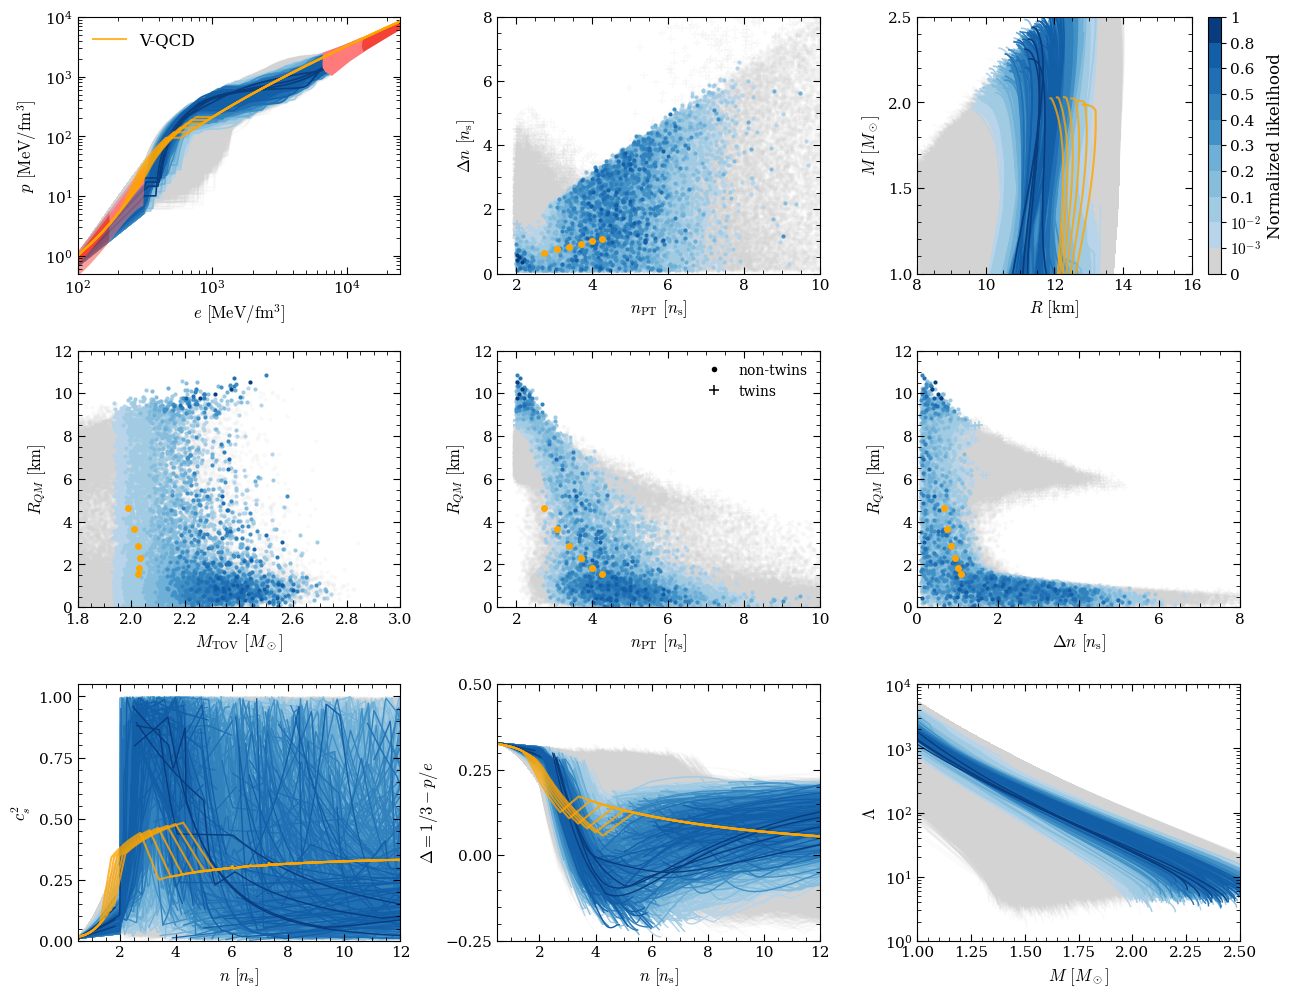

In [13]:
#!/usr/bin/env python3
"""
Plot EOS/TOV results from rank-wise HDF5 files.

This version:
  - Uses stab > 0, so disconnected stable branches labelled 2 are included.
  - Defines M_TOV as max(M) over all stable configurations.
  - Defines R_QM at the stable maximum-mass configuration.
  - Uses full posterior ptot for color normalization by default.
  - Uses + markers for twin-branch points and circle markers for non-twin points.
  - Adds a third row with c_s^2(n), conformal anomaly Delta(n), and Lambda(M).
  - Masks the mixed-phase interval nPT <= n <= nPT + Delta n in the third row.
  - Skips missing/incomplete EOS groups instead of crashing.
  - Keeps compatibility with your plotting modules.
"""

from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator

from modules import plot_settings as ps
from modules import utils as u


# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
INPUT_DIR = Path("../build2")
FILE_PREFIX = ""
FILE_START_INDEX = 0
NUM_FILES = 50
NEOS = 10000  # set to None to auto-detect numeric groups in each file
OUTPUT = "QMcoreEOSs2nsPT_three_rows.pdf"

# Use "ptot" for the full posterior. Alternatives: "pGW_xray", "pGW", "pM".
COLOR_BY = "ptot"

# If True, include only models with stable QM core at M_TOV.
ONLY_QM_CORE_AT_MTOV = True

# Marker convention for scatter-like data points.
# A twin model is defined here as a model whose stable M_TOV point lies on
# a stable branch with label > 1, i.e. usually stab == 2.
NON_TWIN_MARKER = "o"
TWIN_MARKER = "+"
NON_TWIN_MARKERSIZE = 3
TWIN_MARKERSIZE = 6
TWIN_MARKEREDGEWIDTH = 1.1

# Optional V-QCD overlay.
PLOT_VQCD = True
VQCD_FILE = Path("VQCD_data.h5")

# Figure settings.
NROW_FIG = 3
NCOL_FIG = 3
FIGSIZE = (15, 12)

# Axis limits.
RMIN, RMAX = 9, 15
MMIN, MMAX = 1, 2.5
DNMIN, DNMAX = 0, 8
NPTMIN, NPTMAX = 1.5, 10
RQM_MIN, RQM_MAX = 0, 12
MTOV_MIN, MTOV_MAX = 1.8, 3

# Third-row axis limits.
N_DENSITY_MIN, N_DENSITY_MAX = 0.5, 12.0
CS2_MIN, CS2_MAX = 0.0, 1.05
ANOMALY_MIN, ANOMALY_MAX = -0.25, 0.5
LAMBDA_MIN, LAMBDA_MAX = 1.0, 1.0e4


# -----------------------------------------------------------------------------
# HDF5 helpers
# -----------------------------------------------------------------------------
def read_scalar(h5, path, default=np.nan):
    if path not in h5:
        return default
    value = h5[path][()]
    arr = np.asarray(value)
    if arr.shape == ():
        return float(arr)
    if arr.size == 0:
        return default
    return float(arr.flat[0])


def read_array(h5, path):
    if path not in h5:
        raise KeyError(path)
    return h5[path][:]


def numeric_groups(h5):
    return sorted(int(key) for key in h5.keys() if key.isdigit())


def eos_indices(h5, neos):
    if neos is None:
        return numeric_groups(h5)
    return range(neos)


def likelihood_value(h5, base, mode="ptot"):
    params = f"{base}/params"

    if mode == "ptot":
        return read_scalar(h5, f"{params}/ptot", default=0.0)

    if mode == "pM":
        return read_scalar(h5, f"{params}/pM", default=0.0)

    if mode == "pGW":
        return read_scalar(h5, f"{params}/pGW", default=0.0)

    if mode == "pGW_xray":
        p_gw = read_scalar(h5, f"{params}/pGW", default=1.0)
        if f"{params}/pXray" in h5:
            px = np.asarray(h5[f"{params}/pXray"][:], dtype=float)
            # The code may zero-fill unused X-ray slots. Do not multiply zeros
            # from disabled or missing constraints into the diagnostic likelihood.
            positive = px[px > 0]
            p_x = float(np.prod(positive)) if positive.size else 1.0
        else:
            p_x = 1.0
        return p_gw * p_x

    raise ValueError(f"Unknown COLOR_BY mode: {mode}")


def conformal_anomaly(e, p):
    """Return Delta = 1/3 - p/e using matching units for e and p."""
    e = np.asarray(e, dtype=float)
    p = np.asarray(p, dtype=float)
    out = np.full_like(e, np.nan, dtype=float)
    valid = np.isfinite(e) & np.isfinite(p) & (e > 0.0)
    out[valid] = 1.0 / 3.0 - p[valid] / e[valid]
    return out


def outside_mixed_phase_mask(n_over_ns, npt, dn):
    """Mask points outside the first-order mixed phase interval.

    Parameters
    ----------
    n_over_ns:
        Density array in units of n_s.
    npt:
        Left transition density in units of n_s.
    dn:
        Transition strength Delta n in units of n_s.

    Returns
    -------
    mask:
        True outside the interval nPT <= n <= nPT + Delta n.
    """
    n_over_ns = np.asarray(n_over_ns, dtype=float)
    if not np.isfinite(npt) or not np.isfinite(dn) or dn <= 0.0:
        return np.isfinite(n_over_ns)
    return np.isfinite(n_over_ns) & ((n_over_ns < npt) | (n_over_ns > npt + dn))


def contiguous_true_segments(mask):
    """Return contiguous index arrays for True regions of a boolean mask."""
    mask = np.asarray(mask, dtype=bool)
    if mask.size == 0 or not np.any(mask):
        return []

    idx = np.where(mask)[0]
    split_at = np.where(np.diff(idx) > 1)[0] + 1
    return [segment for segment in np.split(idx, split_at) if segment.size >= 2]


def plot_masked_curve(ax, x, y, mask, **kwargs):
    """Plot a curve while breaking it across masked-out regions."""
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.asarray(mask, dtype=bool)
    finite = np.isfinite(x) & np.isfinite(y)
    for segment in contiguous_true_segments(mask & finite):
        ax.plot(x[segment], y[segment], **kwargs)


# -----------------------------------------------------------------------------
# Stability / branch helpers
# -----------------------------------------------------------------------------
def stable_mask(stab):
    """Return all stable configurations. Branch 1 and branch 2 are both stable."""
    return np.asarray(stab) > 0


def stable_branches_from_stab(stab):
    """Return index arrays for each positive stability label."""
    stab = np.asarray(stab)
    branches = []
    for label in sorted(np.unique(stab)):
        if label <= 0:
            continue
        idx = np.where(stab == label)[0]
        if idx.size >= 2:
            branches.append(idx)
    return branches


def stable_mtov_index(M, stab):
    """Index of maximum mass over all stable branches."""
    stable = stable_mask(stab)
    if not np.any(stable):
        return None
    stable_indices = np.where(stable)[0]
    return int(stable_indices[np.argmax(M[stable])])


def is_twin_branch_at_index(stab, idx):
    """Return True if the selected stable point belongs to a twin branch."""
    if idx is None:
        return False
    return int(round(float(stab[idx]))) > 1


def marker_style_for_branch(stab, idx):
    if is_twin_branch_at_index(stab, idx):
        return {
            "marker": TWIN_MARKER,
            "markersize": TWIN_MARKERSIZE,
            "markeredgewidth": TWIN_MARKEREDGEWIDTH,
        }

    return {
        "marker": NON_TWIN_MARKER,
        "markersize": NON_TWIN_MARKERSIZE,
        "markeredgewidth": 0,
    }


def model_has_stable_qm_core_at_mtov(M, stab, Rqm, n_cent, npt):
    idx = stable_mtov_index(M, stab)
    if idx is None:
        return False, None

    has_core = (Rqm[idx] > 0.0) or (n_cent[idx] > npt)
    return bool(has_core), idx


# -----------------------------------------------------------------------------
# Figure setup
# -----------------------------------------------------------------------------
def setup_figure():
    fig, axs = ps.subplot_settings(
        NROW_FIG,
        NCOL_FIG,
        figsize=FIGSIZE,
        wspace=0.3,
        hspace=0.3,
        sharex=False,
        sharey=False,
        squeeze=False,
    )
    ps.configure_plot_style()
    cmap, bounds, norm, cbar = ps.colormap(fig, axs[0, 2], fraction=0.1, pad=0.05)

    axs[0, 0].set_xscale("log")
    axs[0, 0].set_yscale("log")
    axs[0, 0].set_xlim(u.EMIN, u.EMAX)
    axs[0, 0].set_ylim(u.PMIN, u.PMAX)
    axs[0, 0].set_xlabel(r"$e$ $[\mathrm{MeV/fm}^{3}]$")
    axs[0, 0].set_ylabel(r"$p$ $[\mathrm{MeV/fm}^{3}]$")

    axs[0, 1].set_xlim(NPTMIN, NPTMAX)
    axs[0, 1].set_ylim(DNMIN, DNMAX)
    axs[0, 1].set_xlabel(r"$n_{\mathrm{PT}}$ $[n_\mathrm{s}]$")
    axs[0, 1].set_ylabel(r"$\Delta n$ $[n_\mathrm{s}]$")

    axs[0, 2].set_xlim(RMIN, RMAX)
    axs[0, 2].set_ylim(MMIN, MMAX)
    axs[0, 2].set_xlabel(r"$R$ $[\mathrm{km}]$")
    axs[0, 2].set_ylabel(r"$M$ $[M_\odot]$")
    axs[0, 2].set_xticks([8, 10, 12, 14, 16])

    axs[1, 0].set_xlim(MTOV_MIN, MTOV_MAX)
    axs[1, 0].set_ylim(RQM_MIN, RQM_MAX)
    axs[1, 0].set_xlabel(r"$M_{\mathrm{TOV}}$ $[M_\odot]$")
    axs[1, 0].set_ylabel(r"$R_{QM}$ $[\mathrm{km}]$")

    axs[1, 1].set_xlim(NPTMIN, NPTMAX)
    axs[1, 1].set_ylim(RQM_MIN, RQM_MAX)
    axs[1, 1].set_xlabel(r"$n_{\mathrm{PT}}$ $[n_\mathrm{s}]$")
    axs[1, 1].set_ylabel(r"$R_{QM}$ $[\mathrm{km}]$")

    axs[1, 2].set_xlim(DNMIN, DNMAX)
    axs[1, 2].set_ylim(RQM_MIN, RQM_MAX)
    axs[1, 2].set_xlabel(r"$\Delta n$ $[n_\mathrm{s}]$")
    axs[1, 2].set_ylabel(r"$R_{QM}$ $[\mathrm{km}]$")

    axs[2, 0].set_xlim(N_DENSITY_MIN, N_DENSITY_MAX)
    axs[2, 0].set_ylim(CS2_MIN, CS2_MAX)
    axs[2, 0].set_xlabel(r"$n$ $[n_\mathrm{s}]$")
    axs[2, 0].set_ylabel(r"$c_s^2$")

    axs[2, 1].set_xlim(N_DENSITY_MIN, N_DENSITY_MAX)
    axs[2, 1].set_ylim(ANOMALY_MIN, ANOMALY_MAX)
    axs[2, 1].set_xlabel(r"$n$ $[n_\mathrm{s}]$")
    axs[2, 1].set_ylabel(r"$\Delta = 1/3 - p/e$")

    axs[2, 2].set_xlim(MMIN, MMAX)
    axs[2, 2].set_yscale("log")
    axs[2, 2].set_ylim(LAMBDA_MIN, LAMBDA_MAX)
    axs[2, 2].set_xlabel(r"$M$ $[M_\odot]$")
    axs[2, 2].set_ylabel(r"$\Lambda$")

    apply_axis_ticks(axs)

    return fig, axs, cmap, bounds, norm, cbar


def apply_axis_ticks(axs):
    """Enable ticks on all four edges, but labels only on left and bottom."""
    for ax in axs.ravel():
        ax.minorticks_on()
        ax.tick_params(
            axis="both",
            which="major",
            direction="in",
            length=5,
            width=0.8,
            left=True,
            right=True,
            bottom=True,
            top=True,
            labelleft=True,
            labelright=False,
            labelbottom=True,
            labeltop=False,
        )
        ax.tick_params(
            axis="both",
            which="minor",
            direction="in",
            length=3,
            width=0.6,
            left=True,
            right=True,
            bottom=True,
            top=True,
            labelleft=False,
            labelright=False,
            labelbottom=False,
            labeltop=False,
        )
        ax.yaxis.set_tick_params(labelleft=True, labelright=False)
        ax.xaxis.set_tick_params(labelbottom=True, labeltop=False)

    # Explicit y-axis numbers for the linear panels.
    axs[0, 1].set_yticks(np.arange(DNMIN, DNMAX + 0.1, 2))
    axs[0, 2].set_yticks(np.arange(MMIN, MMAX + 0.01, 0.5))
    axs[1, 0].set_yticks(np.arange(RQM_MIN, RQM_MAX + 0.1, 2))
    axs[1, 1].set_yticks(np.arange(RQM_MIN, RQM_MAX + 0.1, 2))
    axs[1, 2].set_yticks(np.arange(RQM_MIN, RQM_MAX + 0.1, 2))
    axs[2, 0].set_yticks(np.arange(CS2_MIN, CS2_MAX + 0.001, 0.25))
    axs[2, 1].set_yticks(np.arange(ANOMALY_MIN, ANOMALY_MAX + 0.001, 0.25))

    # Log panels: labeled major ticks, unlabeled minor ticks.
    for log_ax in [axs[0, 0], axs[2, 2]]:
        log_ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=8))
        log_ax.yaxis.set_minor_locator(
            LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=80)
        )
        log_ax.yaxis.set_minor_formatter(plt.NullFormatter())


# -----------------------------------------------------------------------------
# Data scan and plotting
# -----------------------------------------------------------------------------
def compute_max_likelihood():
    max_like = 0.0
    for k in range(FILE_START_INDEX, FILE_START_INDEX + NUM_FILES):
        path = INPUT_DIR / f"{FILE_PREFIX}{k}.h5"
        if not path.exists():
            continue
        with h5py.File(path, "r") as h5:
            for i in eos_indices(h5, NEOS):
                base = f"/{i}"
                if f"{base}/params" not in h5:
                    continue
                val = likelihood_value(h5, base, COLOR_BY)
                if np.isfinite(val):
                    max_like = max(max_like, val)
    return max_like if max_like > 0 else 1.0


def plot_results():
    fig, axs, cmap, bounds, norm, cbar = setup_figure()
    max_like = compute_max_likelihood()
    threshold = bounds[1]

    print(f"Coloring by {COLOR_BY}; max likelihood = {max_like:.6e}; threshold = {threshold}")

    qm_count = 0
    twin_point_count = 0
    non_twin_point_count = 0
    plotted_count = 0
    skipped_count = 0

    for k in range(FILE_START_INDEX, FILE_START_INDEX + NUM_FILES):
        path = INPUT_DIR / f"{FILE_PREFIX}{k}.h5"
        print(path)
        if not path.exists():
            print("  missing, skipping")
            continue

        with h5py.File(path, "r") as h5:
            for i in eos_indices(h5, NEOS):
                base = f"/{i}"
                tov_path = f"{base}/TOV"
                eos_path = f"{base}/EOS"
                params_path = f"{base}/params"

                required = [
                    f"{tov_path}/M",
                    f"{tov_path}/R",
                    f"{tov_path}/Rqm",
                    f"{tov_path}/stab",
                    f"{tov_path}/n_cent",
                    f"{tov_path}/Lambda",
                    f"{eos_path}/e",
                    f"{eos_path}/p",
                    f"{eos_path}/n",
                    f"{eos_path}/cs2",
                    f"{params_path}/dn",
                    f"{params_path}/nPTl",
                ]
                if any(req not in h5 for req in required):
                    skipped_count += 1
                    continue

                try:
                    M = read_array(h5, f"{tov_path}/M")
                    R = read_array(h5, f"{tov_path}/R")
                    Rqm = read_array(h5, f"{tov_path}/Rqm")
                    stab = read_array(h5, f"{tov_path}/stab")
                    n_cent = read_array(h5, f"{tov_path}/n_cent") / u.ns
                    lambda_data = read_array(h5, f"{tov_path}/Lambda")

                    e_data = read_array(h5, f"{eos_path}/e")
                    p_data = read_array(h5, f"{eos_path}/p")
                    n_data = read_array(h5, f"{eos_path}/n") / u.ns
                    cs2_data = read_array(h5, f"{eos_path}/cs2")
                    anomaly_data = conformal_anomaly(e_data, p_data)

                    dn = read_scalar(h5, f"{params_path}/dn")
                    npt = read_scalar(h5, f"{params_path}/nPTl") / u.ns
                except Exception:
                    skipped_count += 1
                    continue

                has_core, mtov_idx = model_has_stable_qm_core_at_mtov(M, stab, Rqm, n_cent, npt)
                if mtov_idx is None:
                    skipped_count += 1
                    continue
                if ONLY_QM_CORE_AT_MTOV and not has_core:
                    continue

                qm_count += int(has_core)
                Mtov = M[mtov_idx]
                Rqm_at_mtov = Rqm[mtov_idx]
                marker_style = marker_style_for_branch(stab, mtov_idx)
                is_twin = is_twin_branch_at_index(stab, mtov_idx)
                if is_twin:
                    twin_point_count += 1
                else:
                    non_twin_point_count += 1

                like = likelihood_value(h5, base, COLOR_BY)
                normalized = like / max_like if max_like > 0 else 0.0
                normalized = float(np.clip(normalized, 0.0, 1.0))

                if normalized < threshold:
                    color = "lightgrey"
                    alpha = 0.12
                    zorder = 0
                else:
                    color = cmap(norm(normalized))
                    alpha = 1.0
                    zorder = np.searchsorted(bounds, normalized) / max(1, len(bounds) - 1)

                axs[0, 0].plot(e_data, p_data, color=color, linewidth=1.2, zorder=zorder, alpha=alpha, rasterized=True)

                eos_non_mixed = outside_mixed_phase_mask(n_data, npt, dn)
                plot_masked_curve(
                    axs[2, 0],
                    n_data,
                    cs2_data,
                    eos_non_mixed,
                    color=color,
                    linewidth=1.0,
                    zorder=zorder,
                    alpha=alpha,
                    rasterized=True,
                )
                plot_masked_curve(
                    axs[2, 1],
                    n_data,
                    anomaly_data,
                    eos_non_mixed,
                    color=color,
                    linewidth=1.0,
                    zorder=zorder,
                    alpha=alpha,
                    rasterized=True,
                )

                axs[0, 1].plot(npt, dn, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)
                axs[1, 0].plot(Mtov, Rqm_at_mtov, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)
                axs[1, 1].plot(npt, Rqm_at_mtov, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)
                axs[1, 2].plot(dn, Rqm_at_mtov, color=color, zorder=zorder, alpha=alpha, rasterized=True, linestyle="None", **marker_style)

                tov_non_mixed = outside_mixed_phase_mask(n_cent, npt, dn)
                for branch in stable_branches_from_stab(stab):
                    axs[0, 2].plot(R[branch], M[branch], color=color, linewidth=1.2, zorder=zorder, alpha=alpha, rasterized=True)
                    lambda_mask = tov_non_mixed[branch]
                    plot_masked_curve(
                        axs[2, 2],
                        M[branch],
                        lambda_data[branch],
                        lambda_mask,
                        color=color,
                        linewidth=1.0,
                        zorder=zorder,
                        alpha=alpha,
                        rasterized=True,
                    )

                plotted_count += 1

    print("number of plotted stable QM-core models:", qm_count)
    print("number of plotted twin-branch points:", twin_point_count)
    print("number of plotted non-twin points:", non_twin_point_count)
    print("number of plotted models:", plotted_count)
    print("number of skipped incomplete models:", skipped_count)

    add_vqcd_overlay(axs)
    add_eos_constraint_regions(axs)

    add_marker_legend(axs)
    axs[0, 0].legend(loc="upper left", frameon=False, fontsize=12)
    plt.savefig(OUTPUT, dpi=300, bbox_inches="tight")
    print(f"Saved {OUTPUT}")


def add_marker_legend(axs):
    """Add a marker legend to the nPT-Rqm panel."""
    non_twin = plt.Line2D(
        [], [],
        color="black",
        marker=NON_TWIN_MARKER,
        linestyle="None",
        markersize=NON_TWIN_MARKERSIZE + 1,
        markeredgewidth=0,
        label="non-twins",
    )
    twin = plt.Line2D(
        [], [],
        color="black",
        marker=TWIN_MARKER,
        linestyle="None",
        markersize=TWIN_MARKERSIZE + 1,
        markeredgewidth=TWIN_MARKEREDGEWIDTH,
        label="twins",
    )
    axs[1, 1].legend(
        handles=[non_twin, twin],
        loc="upper right",
        frameon=False,
        fontsize=10,
    )


# -----------------------------------------------------------------------------
# Overlays
# -----------------------------------------------------------------------------
def add_vqcd_overlay(axs):
    if not PLOT_VQCD or not VQCD_FILE.exists():
        return

    gev3_to_invfm3 = 5.067730756672362 ** 3
    gev4_to_mevfm3 = 130149.0
    ns = 0.16

    with h5py.File(VQCD_FILE, "r") as h5:
        for j, key in enumerate(numeric_groups(h5)):
            base = f"/{key}"
            try:
                stab = read_array(h5, f"{base}/TOV/stab")
                stable = stable_mask(stab)
                if not np.any(stable):
                    continue

                R = read_array(h5, f"{base}/TOV/R")[stable]
                M = read_array(h5, f"{base}/TOV/M")[stable]
                Mtov = float(np.max(M))

                Rqm = read_array(h5, f"{base}/TOV/Rqm")[stable]
                RqmTOV = Rqm[np.argmax(M)]

                p_data = read_array(h5, f"{base}/EOS/p") * gev4_to_mevfm3
                e_data = read_array(h5, f"{base}/EOS/e") * gev4_to_mevfm3
                n_data = read_array(h5, f"{base}/EOS/n") * gev3_to_invfm3 / ns

                if f"{base}/EOS/cs2" in h5:
                    cs2_data = read_array(h5, f"{base}/EOS/cs2")
                else:
                    cs2_data = np.gradient(p_data, e_data)

                anomaly_data = conformal_anomaly(e_data, p_data)
                lambda_data = read_array(h5, f"{base}/TOV/Lambda")[stable] if f"{base}/TOV/Lambda" in h5 else None
                n_cent_vqcd = read_array(h5, f"{base}/TOV/n_cent")[stable] * gev3_to_invfm3 / ns if f"{base}/TOV/n_cent" in h5 else None

                npt = read_scalar(h5, f"{base}/params/nPT") * gev3_to_invfm3 / ns
                dn = read_scalar(h5, f"{base}/params/Dn") * gev3_to_invfm3 / ns
            except Exception:
                continue

            label = "V-QCD" if j == 0 else None
            axs[0, 0].plot(e_data, p_data, color="orange", linewidth=1.5, zorder=2, alpha=0.8, label=label)
            axs[0, 1].plot(npt, dn, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)
            axs[0, 2].plot(R, M, color="orange", linewidth=1.5, zorder=2, alpha=0.8)

            axs[1, 0].plot(Mtov, RqmTOV, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)
            axs[1, 1].plot(npt, RqmTOV, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)
            axs[1, 2].plot(dn, RqmTOV, marker="o", color="orange", markersize=5, markeredgewidth=0, zorder=2)

            eos_non_mixed = outside_mixed_phase_mask(n_data, npt, dn)
            plot_masked_curve(axs[2, 0], n_data/3, cs2_data, eos_non_mixed, color="orange", linewidth=1.5, zorder=2, alpha=0.8)
            plot_masked_curve(axs[2, 1], n_data/3, anomaly_data, eos_non_mixed, color="orange", linewidth=1.5, zorder=2, alpha=0.8)
            if lambda_data is not None:
                if n_cent_vqcd is not None:
                    tov_non_mixed = outside_mixed_phase_mask(n_cent_vqcd, npt, dn)
                else:
                    tov_non_mixed = np.ones_like(M, dtype=bool)
                plot_masked_curve(axs[2, 2], M, lambda_data, tov_non_mixed, color="orange", linewidth=1.5, zorder=2, alpha=0.8)


def add_eos_constraint_regions(axs):
    axs[0, 0].fill(u.cs2boundary[:, 0], u.cs2boundary[:, 1], zorder=1.4, facecolor=u.cs2_color, edgecolor=None)
    axs[0, 0].fill(u.pQCDpoints[:, 0], u.pQCDpoints[:, 1], facecolor=u.pQCD_color, edgecolor=None, zorder=1.5)
    axs[0, 0].fill(u.boundary_ep_1ns_1s[:, 0], u.boundary_ep_1ns_1s[:, 1], facecolor=u.CET_1ns_color, edgecolor=None, zorder=1.5, alpha=1)
    axs[0, 0].fill(u.boundary_ep_2ns_1s[:, 0], u.boundary_ep_2ns_1s[:, 1], facecolor=u.CET_2ns_color, edgecolor=None, zorder=1.5, alpha=1)
    axs[0, 0].fill(u.boundary_ep_1ns_2s[:, 0], u.boundary_ep_1ns_2s[:, 1], facecolor=u.CET_1ns_color, edgecolor=None, zorder=1.5, alpha=0.5)
    axs[0, 0].fill(u.boundary_ep_2ns_2s[:, 0], u.boundary_ep_2ns_2s[:, 1], facecolor=u.CET_2ns_color, edgecolor=None, zorder=1.5, alpha=0.5)


if __name__ == "__main__":
    plot_results()

# Tidal defomability

Coloring by ptot
max likelihood = 7.623950e-03
threshold = 0.001
../build2/0.h5
../build2/1.h5
../build2/2.h5
../build2/3.h5
../build2/4.h5
../build2/5.h5
../build2/6.h5
../build2/7.h5
../build2/8.h5
../build2/9.h5
../build2/10.h5
../build2/11.h5
../build2/12.h5
../build2/13.h5
../build2/14.h5
../build2/15.h5
../build2/16.h5
../build2/17.h5
../build2/18.h5
../build2/19.h5
../build2/20.h5
../build2/21.h5
../build2/22.h5
../build2/23.h5
../build2/24.h5
../build2/25.h5
../build2/26.h5
../build2/27.h5
../build2/28.h5
../build2/29.h5
../build2/30.h5
../build2/31.h5
../build2/32.h5
../build2/33.h5
../build2/34.h5
../build2/35.h5
../build2/36.h5
../build2/37.h5
../build2/38.h5
../build2/39.h5
../build2/40.h5
../build2/41.h5
../build2/42.h5
../build2/43.h5
../build2/44.h5
../build2/45.h5
../build2/46.h5
../build2/47.h5
../build2/48.h5
../build2/49.h5
Plotted models: 1024
Skipped incomplete models: 0
Saved Lambda_vs_M_colored.pdf


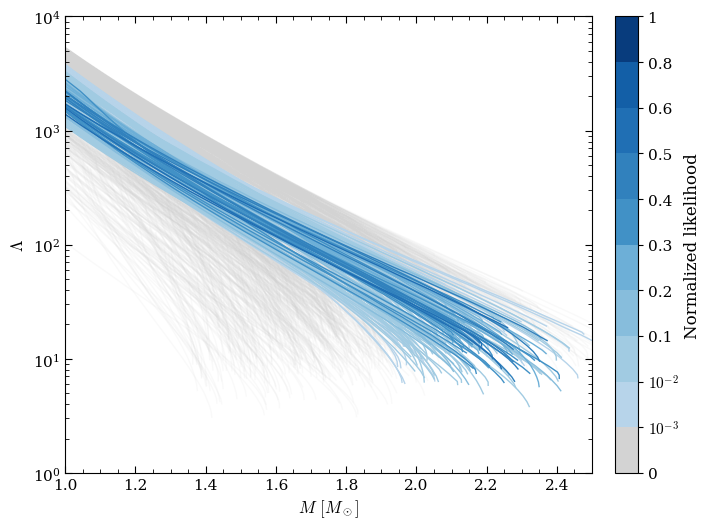

In [3]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator

from modules import plot_settings as ps


# =============================================================================
# CONFIG
# =============================================================================

INPUT_DIR = Path("../build2")
FILE_PREFIX = ""
FILE_START_INDEX = 0
NUM_FILES = 50

# Set to None to auto-detect all numeric groups in each file.
# Or set, for example, NEOS = 10000 if each file contains /0 ... /9999.
NEOS = 100

OUTPUT = "Lambda_vs_M_colored.pdf"
SAVE_FIGURE = True

# Use "ptot" for the full posterior.
# Alternatives: "pGW_xray", "pGW", "pM".
COLOR_BY = "ptot"

# Plot only models with a stable quark-matter core at M_TOV.
ONLY_QM_CORE_AT_MTOV = True

# Saturation density used by the code, in fm^-3.
NS = 0.16

# Axis limits.
MMIN, MMAX = 1.0, 2.5
LAMBDA_MIN, LAMBDA_MAX = 1.0, 1.0e4

FIGSIZE = (7.2, 5.4)


# =============================================================================
# HDF5 HELPERS
# =============================================================================

def read_scalar(h5, path, default=np.nan):
    if path not in h5:
        return default

    value = h5[path][()]
    arr = np.asarray(value)

    if arr.shape == ():
        return float(arr)

    if arr.size == 0:
        return default

    return float(arr.flat[0])


def read_array(h5, path):
    if path not in h5:
        raise KeyError(path)
    return np.asarray(h5[path][:], dtype=float)


def numeric_groups(h5):
    return sorted(int(key) for key in h5.keys() if key.isdigit())


def eos_indices(h5, neos):
    if neos is None:
        return numeric_groups(h5)
    return range(neos)


def likelihood_value(h5, base, mode="ptot"):
    params = f"{base}/params"

    if mode == "ptot":
        return read_scalar(h5, f"{params}/ptot", default=0.0)

    if mode == "pM":
        return read_scalar(h5, f"{params}/pM", default=0.0)

    if mode == "pGW":
        return read_scalar(h5, f"{params}/pGW", default=0.0)

    if mode == "pGW_xray":
        p_gw = read_scalar(h5, f"{params}/pGW", default=1.0)

        if f"{params}/pXray" in h5:
            px = np.asarray(h5[f"{params}/pXray"][:], dtype=float)
            positive = px[px > 0]
            p_x = float(np.prod(positive)) if positive.size else 1.0
        else:
            p_x = 1.0

        return p_gw * p_x

    raise ValueError(f"Unknown COLOR_BY mode: {mode}")


# =============================================================================
# STABILITY / BRANCH HELPERS
# =============================================================================

def stable_mask(stab):
    """Stable configurations have positive stability labels."""
    return np.asarray(stab) > 0


def stable_branches_from_stab(stab):
    """Return one index array per stable branch."""
    stab = np.asarray(stab)
    branches = []

    for label in sorted(np.unique(stab)):
        if label <= 0:
            continue

        idx = np.where(stab == label)[0]

        if idx.size >= 2:
            branches.append(idx)

    return branches


def stable_mtov_index(M, stab):
    """Return the index of the maximum mass over all stable branches."""
    stable = stable_mask(stab)

    if not np.any(stable):
        return None

    stable_indices = np.where(stable)[0]
    return int(stable_indices[np.argmax(M[stable])])


def model_has_stable_qm_core_at_mtov(M, stab, Rqm, n_cent, npt):
    """Check whether the stable maximum-mass configuration has a QM core."""
    idx = stable_mtov_index(M, stab)

    if idx is None:
        return False, None

    has_core = (Rqm[idx] > 0.0) or (n_cent[idx] > npt)
    return bool(has_core), idx


def outside_mixed_phase_mask(n_over_ns, npt, dn):
    """Mask out the mixed phase nPT <= n <= nPT + Delta n."""
    n_over_ns = np.asarray(n_over_ns, dtype=float)

    if not np.isfinite(npt) or not np.isfinite(dn) or dn <= 0.0:
        return np.isfinite(n_over_ns)

    return np.isfinite(n_over_ns) & (
        (n_over_ns < npt) | (n_over_ns > npt + dn)
    )


def contiguous_true_segments(mask):
    """Return contiguous index arrays for True regions."""
    mask = np.asarray(mask, dtype=bool)

    if mask.size == 0 or not np.any(mask):
        return []

    idx = np.where(mask)[0]
    split_at = np.where(np.diff(idx) > 1)[0] + 1

    return [
        segment
        for segment in np.split(idx, split_at)
        if segment.size >= 2
    ]


def plot_masked_curve(ax, x, y, mask, **kwargs):
    """Plot a curve while breaking it across masked-out regions."""
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.asarray(mask, dtype=bool)

    finite = np.isfinite(x) & np.isfinite(y)

    for segment in contiguous_true_segments(mask & finite):
        ax.plot(x[segment], y[segment], **kwargs)


# =============================================================================
# LIKELIHOOD NORMALIZATION
# =============================================================================

def compute_max_likelihood():
    max_like = 0.0

    for k in range(FILE_START_INDEX, FILE_START_INDEX + NUM_FILES):
        path = INPUT_DIR / f"{FILE_PREFIX}{k}.h5"

        if not path.exists():
            continue

        with h5py.File(path, "r") as h5:
            for i in eos_indices(h5, NEOS):
                base = f"/{i}"

                if f"{base}/params" not in h5:
                    continue

                val = likelihood_value(h5, base, COLOR_BY)

                if np.isfinite(val):
                    max_like = max(max_like, val)

    return max_like if max_like > 0.0 else 1.0


# =============================================================================
# FIGURE SETUP
# =============================================================================

ps.configure_plot_style()

fig, ax = plt.subplots(figsize=FIGSIZE)

# Dummy axis for the colorbar placement, similar to the old multi-panel script.
# The colormap helper attaches a colorbar to the supplied axis.
cmap, bounds, norm, cbar = ps.colormap(fig, ax, fraction=0.045, pad=0.04)

max_like = compute_max_likelihood()
threshold = bounds[1]

print(f"Coloring by {COLOR_BY}")
print(f"max likelihood = {max_like:.6e}")
print(f"threshold = {threshold}")


# =============================================================================
# PLOT
# =============================================================================

plotted_count = 0
skipped_count = 0

for k in range(FILE_START_INDEX, FILE_START_INDEX + NUM_FILES):
    path = INPUT_DIR / f"{FILE_PREFIX}{k}.h5"
    print(path)

    if not path.exists():
        print("  missing, skipping")
        continue

    with h5py.File(path, "r") as h5:
        for i in eos_indices(h5, NEOS):
            base = f"/{i}"
            tov_path = f"{base}/TOV"
            params_path = f"{base}/params"

            required = [
                f"{tov_path}/M",
                f"{tov_path}/Lambda",
                f"{tov_path}/stab",
                f"{tov_path}/Rqm",
                f"{tov_path}/n_cent",
                f"{params_path}/nPTl",
                f"{params_path}/dn",
                f"{params_path}/{COLOR_BY}" if COLOR_BY in ["ptot", "pM", "pGW"] else f"{params_path}/pGW",
            ]

            if any(req not in h5 for req in required):
                skipped_count += 1
                continue

            try:
                M = read_array(h5, f"{tov_path}/M")
                Lambda = read_array(h5, f"{tov_path}/Lambda")
                stab = read_array(h5, f"{tov_path}/stab")
                Rqm = read_array(h5, f"{tov_path}/Rqm")
                n_cent = read_array(h5, f"{tov_path}/n_cent") / NS

                npt = read_scalar(h5, f"{params_path}/nPTl") / NS
                dn = read_scalar(h5, f"{params_path}/dn")

                like = likelihood_value(h5, base, COLOR_BY)
            except Exception:
                skipped_count += 1
                continue

            has_core, mtov_idx = model_has_stable_qm_core_at_mtov(
                M,
                stab,
                Rqm,
                n_cent,
                npt,
            )

            if mtov_idx is None:
                skipped_count += 1
                continue

            if ONLY_QM_CORE_AT_MTOV and not has_core:
                continue

            normalized = like / max_like if max_like > 0.0 else 0.0
            normalized = float(np.clip(normalized, 0.0, 1.0))

            if normalized < threshold:
                color = "lightgrey"
                alpha = 0.12
                zorder = 0
            else:
                color = cmap(norm(normalized))
                alpha = 1.0
                zorder = np.searchsorted(bounds, normalized) / max(1, len(bounds) - 1)

            # Mask out configurations whose central density lies in the mixed phase.
            non_mixed = outside_mixed_phase_mask(n_cent, npt, dn)

            for branch in stable_branches_from_stab(stab):
                plot_masked_curve(
                    ax,
                    M[branch],
                    Lambda[branch],
                    non_mixed[branch],
                    color=color,
                    linewidth=1.0,
                    zorder=zorder,
                    alpha=alpha,
                    rasterized=True,
                )

            plotted_count += 1


print(f"Plotted models: {plotted_count}")
print(f"Skipped incomplete models: {skipped_count}")


# =============================================================================
# AXIS FORMATTING
# =============================================================================

ax.set_yscale("log")
ax.set_xlim(MMIN, MMAX)
ax.set_ylim(LAMBDA_MIN, LAMBDA_MAX)

ax.set_xlabel(r"$M$ $[M_\odot]$")
ax.set_ylabel(r"$\Lambda$")

ax.minorticks_on()
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    length=5,
    width=0.8,
    left=True,
    right=True,
    bottom=True,
    top=True,
    labelleft=True,
    labelright=False,
    labelbottom=True,
    labeltop=False,
)
ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    length=3,
    width=0.6,
    left=True,
    right=True,
    bottom=True,
    top=True,
    labelleft=False,
    labelright=False,
    labelbottom=False,
    labeltop=False,
)

ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=8))
ax.yaxis.set_minor_locator(
    LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=80)
)
ax.yaxis.set_minor_formatter(plt.NullFormatter())

plt.tight_layout()

if SAVE_FIGURE:
    plt.savefig(OUTPUT, dpi=300, bbox_inches="tight")
    print(f"Saved {OUTPUT}")

plt.show()

../build2/0.h5
../build2/1.h5
../build2/2.h5
../build2/3.h5
../build2/4.h5
../build2/5.h5
../build2/6.h5
../build2/7.h5
../build2/8.h5
../build2/9.h5
../build2/10.h5
../build2/11.h5
../build2/12.h5
../build2/13.h5
../build2/14.h5
../build2/15.h5
../build2/16.h5
../build2/17.h5
../build2/18.h5
../build2/19.h5
../build2/20.h5
../build2/21.h5
../build2/22.h5
../build2/23.h5
../build2/24.h5
../build2/25.h5
../build2/26.h5
../build2/27.h5
../build2/28.h5
../build2/29.h5
../build2/30.h5
../build2/31.h5
../build2/32.h5
../build2/33.h5
../build2/34.h5
../build2/35.h5
../build2/36.h5
../build2/37.h5
../build2/38.h5
../build2/39.h5
../build2/40.h5
../build2/41.h5
../build2/42.h5
../build2/43.h5
../build2/44.h5
../build2/45.h5
../build2/46.h5
../build2/47.h5
../build2/48.h5
../build2/49.h5

Coloring by ptot
max likelihood among plotted models = 6.811903e-03
valid plotted EOS models = 10278
missing files = 0
skipped models = 39722
threshold = 0.001

Plotted EOS models: 10278
Skipped EOS models aft

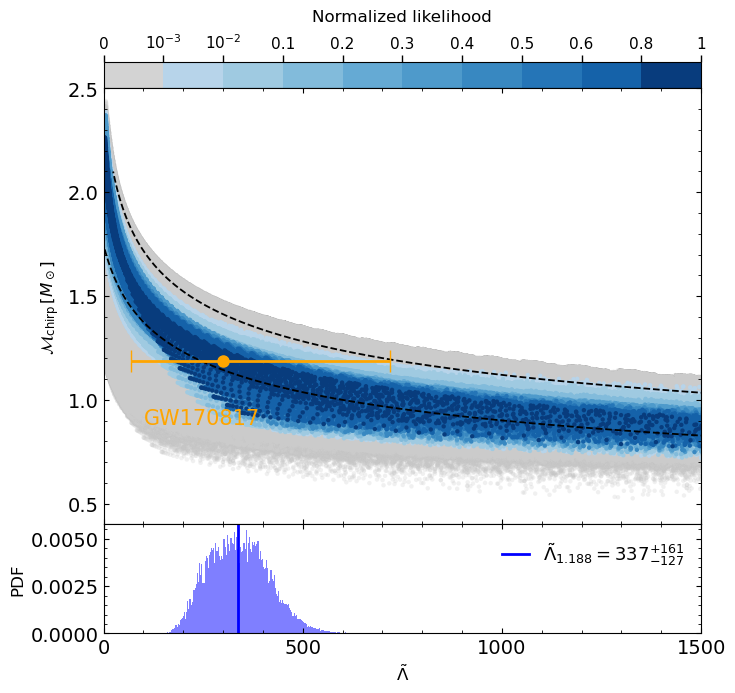

In [ ]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.ticker import MultipleLocator

from modules import plot_settings as ps


# =============================================================================
# CONFIG
# =============================================================================

INPUT_DIR = Path("../build2")
FILE_PREFIX = ""
FILE_START_INDEX = 0
NUM_FILES = 50

# Set to None to auto-detect numeric groups.
# Or set, e.g. NEOS = 10000 if each file contains /0 ... /9999.
NEOS = 1000

OUTPUT = "chirp_mass_vs_Lambda_tilde.pdf"
SAVE_FIGURE = True

# Use "ptot" for full posterior. Alternatives: "pGW_xray", "pGW", "pM".
COLOR_BY = "ptot"

# If True, include only models with a stable QM core at M_TOV.
ONLY_QM_CORE_AT_MTOV = True

# Saturation density in fm^-3.
NS = 0.16

# Component-mass cut for binary construction.
MIN_COMPONENT_MASS = 0.5

# Optional downsampling of binary pairs per EOS for speed.
# Set to None to plot all pairs.
MAX_PAIRS_PER_EOS = None

# Chirp-mass slice for the lower PDF panel.
MCHIRP_SLICE = 1.188
DMCHIRP = 0.01

# Histogram settings.
N_HIST_BINS = 400
N_QUANTILE_BINS = 800

# Figure and axis limits.
FIGSIZE = (7.2, 6.8)
LTILDE_MIN, LTILDE_MAX = 0.0, 1500.0
MCHIRP_MIN, MCHIRP_MAX = 0.4, 2.5

# GW170817 marker/errorbar.
PLOT_GW170817 = True
GW170817_MCHIRP = 1.188
GW170817_LTILDE = 300.0
GW170817_LTILDE_ERR_LOW = 230.0
GW170817_LTILDE_ERR_HIGH = 420.0

# Analytic guide curves from your reference script.
PLOT_GUIDE_CURVES = False


# =============================================================================
# STYLE
# =============================================================================

ps.configure_plot_style()

# Override unavailable Computer Modern settings from ps.configure_plot_style().
# This keeps the same general style but suppresses font warnings.
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "DejaVu Sans",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavusans",
})


# =============================================================================
# HDF5 HELPERS
# =============================================================================

def read_scalar(h5, path, default=np.nan):
    if path not in h5:
        return default

    value = h5[path][()]
    arr = np.asarray(value)

    if arr.shape == ():
        return float(arr)

    if arr.size == 0:
        return default

    return float(arr.flat[0])


def read_array(h5, path):
    if path not in h5:
        raise KeyError(path)

    return np.asarray(h5[path][:], dtype=float)


def numeric_groups(h5):
    return sorted(int(key) for key in h5.keys() if key.isdigit())


def eos_indices(h5, neos):
    if neos is None:
        return numeric_groups(h5)

    return range(neos)


def likelihood_value(h5, base, mode="ptot"):
    params = f"{base}/params"

    if mode == "ptot":
        return read_scalar(h5, f"{params}/ptot", default=0.0)

    if mode == "pM":
        return read_scalar(h5, f"{params}/pM", default=0.0)

    if mode == "pGW":
        return read_scalar(h5, f"{params}/pGW", default=0.0)

    if mode == "pGW_xray":
        p_gw = read_scalar(h5, f"{params}/pGW", default=1.0)

        if f"{params}/pXray" in h5:
            px = np.asarray(h5[f"{params}/pXray"][:], dtype=float)
            positive = px[px > 0]
            p_x = float(np.prod(positive)) if positive.size else 1.0
        else:
            p_x = 1.0

        return p_gw * p_x

    raise ValueError(f"Unknown COLOR_BY mode: {mode}")


# =============================================================================
# TOV / BRANCH HELPERS
# =============================================================================

def stable_mask(stab):
    return np.asarray(stab) > 0


def stable_mtov_index(M, stab):
    stable = stable_mask(stab)

    if not np.any(stable):
        return None

    stable_indices = np.where(stable)[0]

    return int(stable_indices[np.argmax(M[stable])])


def model_has_stable_qm_core_at_mtov(M, stab, Rqm, n_cent, npt):
    idx = stable_mtov_index(M, stab)

    if idx is None:
        return False, None

    has_core = (Rqm[idx] > 0.0) or (n_cent[idx] > npt)

    return bool(has_core), idx


def select_stable_mass_lambda(M, Lambda, stab):
    """
    Select all stable configurations, including disconnected stable branches
    labelled stab == 2, 3, ...
    """
    M = np.asarray(M, dtype=float)
    Lambda = np.asarray(Lambda, dtype=float)
    stab = np.asarray(stab, dtype=float)

    mask = (
        (stab > 0)
        & np.isfinite(M)
        & np.isfinite(Lambda)
        & (M > MIN_COMPONENT_MASS)
        & (Lambda > 0.0)
    )

    M_stable = M[mask]
    Lambda_stable = Lambda[mask]

    if M_stable.size < 2:
        return None, None

    order = np.argsort(M_stable)

    return M_stable[order], Lambda_stable[order]


# =============================================================================
# BINARY FUNCTIONS
# =============================================================================

def chirp_mass(m1, m2):
    return (m1 * m2)**(3.0 / 5.0) / (m1 + m2)**(1.0 / 5.0)


def lambda_tilde(m1, m2, l1, l2):
    return (
        16.0 / 13.0
        * (
            (12.0 * m2 + m1) * m1**4 * l1
            + (12.0 * m1 + m2) * m2**4 * l2
        )
        / (m1 + m2)**5
    )


def binary_pairs_from_sequence(M, Lambda):
    """
    Generate all binary pairs with j <= i, i.e. m1 >= m2,
    including equal-mass pairs.
    """
    M = np.asarray(M, dtype=float)
    Lambda = np.asarray(Lambda, dtype=float)

    Mc_values = []
    Lt_values = []

    for i in range(len(M)):
        m1 = M[i]
        l1 = Lambda[i]

        for j in range(i + 1):
            m2 = M[j]
            l2 = Lambda[j]

            if m2 <= MIN_COMPONENT_MASS:
                continue

            Mc_values.append(chirp_mass(m1, m2))
            Lt_values.append(lambda_tilde(m1, m2, l1, l2))

    Mc_values = np.asarray(Mc_values, dtype=float)
    Lt_values = np.asarray(Lt_values, dtype=float)

    finite = (
        np.isfinite(Mc_values)
        & np.isfinite(Lt_values)
        & (Lt_values > 0.0)
    )

    return Mc_values[finite], Lt_values[finite]


def maybe_downsample(Mc, Lt, max_pairs, rng):
    if max_pairs is None:
        return Mc, Lt

    if Mc.size <= max_pairs:
        return Mc, Lt

    idx = rng.choice(Mc.size, size=max_pairs, replace=False)

    return Mc[idx], Lt[idx]


# =============================================================================
# MODEL LOADING
# =============================================================================

def load_plotting_inputs(h5, base):
    tov_path = f"{base}/TOV"
    params_path = f"{base}/params"

    required = [
        f"{tov_path}/M",
        f"{tov_path}/Lambda",
        f"{tov_path}/stab",
        f"{tov_path}/Rqm",
        f"{tov_path}/n_cent",
        f"{params_path}/nPTl",
        f"{params_path}/dn",
        f"{params_path}/{COLOR_BY}"
        if COLOR_BY in ["ptot", "pM", "pGW"]
        else f"{params_path}/pGW",
    ]

    if any(req not in h5 for req in required):
        return None

    try:
        M = read_array(h5, f"{tov_path}/M")
        Lambda = read_array(h5, f"{tov_path}/Lambda")
        stab = read_array(h5, f"{tov_path}/stab")
        Rqm = read_array(h5, f"{tov_path}/Rqm")
        n_cent = read_array(h5, f"{tov_path}/n_cent") / NS
        npt = read_scalar(h5, f"{params_path}/nPTl") / NS
        like = likelihood_value(h5, base, COLOR_BY)
    except Exception:
        return None

    if not np.isfinite(like) or like < 0.0:
        return None

    has_core, mtov_idx = model_has_stable_qm_core_at_mtov(
        M,
        stab,
        Rqm,
        n_cent,
        npt,
    )

    if mtov_idx is None:
        return None

    if ONLY_QM_CORE_AT_MTOV and not has_core:
        return None

    M_stable, Lambda_stable = select_stable_mass_lambda(M, Lambda, stab)

    if M_stable is None:
        return None

    return {
        "M": M_stable,
        "Lambda": Lambda_stable,
        "like": like,
    }


def collect_eos_models():
    """
    Scan files once and keep only EOSs that pass the same cuts used for plotting.

    This makes likelihood normalization consistent with what is actually shown:
        normalized = like / max_like_among_plotted_models
    """
    models = []
    missing_files = 0
    skipped_models = 0

    for k in range(FILE_START_INDEX, FILE_START_INDEX + NUM_FILES):
        path = INPUT_DIR / f"{FILE_PREFIX}{k}.h5"
        print(path)

        if not path.exists():
            print("  missing, skipping")
            missing_files += 1
            continue

        with h5py.File(path, "r") as h5:
            for i in eos_indices(h5, NEOS):
                base = f"/{i}"

                model = load_plotting_inputs(h5, base)

                if model is None:
                    skipped_models += 1
                    continue

                model["file_index"] = k
                model["eos_index"] = i
                models.append(model)

    return models, missing_files, skipped_models


# =============================================================================
# HISTOGRAM / QUANTILES
# =============================================================================

def interp_quantile(bin_edges, cum, q):
    """
    Return q-th quantile from a normalized cumulative histogram.
    """
    if cum.size == 0 or not np.isfinite(cum[-1]) or cum[-1] <= 0.0:
        return np.nan

    i = np.searchsorted(cum, q)

    if i <= 0:
        return 0.5 * (bin_edges[0] + bin_edges[1])

    if i >= len(cum):
        return 0.5 * (bin_edges[-2] + bin_edges[-1])

    cdf_prev = cum[i - 1]
    cdf_bin = cum[i] - cdf_prev

    if cdf_bin <= 0.0:
        return 0.5 * (bin_edges[i] + bin_edges[i + 1])

    frac = (q - cdf_prev) / cdf_bin

    left = bin_edges[i]
    right = bin_edges[i + 1]

    return left + frac * (right - left)


def weighted_quantiles_from_hist(values, weights, bins):
    counts, bin_edges = np.histogram(values, weights=weights, bins=bins)

    if np.sum(counts) <= 0.0:
        return np.nan, np.nan, np.nan, counts, bin_edges

    cum = np.cumsum(counts)
    cum = cum / cum[-1]

    median = interp_quantile(bin_edges, cum, 0.5)
    lower_95 = interp_quantile(bin_edges, cum, 0.025)
    upper_95 = interp_quantile(bin_edges, cum, 0.975)

    return median, lower_95, upper_95, counts, bin_edges


# =============================================================================
# FIGURE SETUP
# =============================================================================

rng = np.random.default_rng(12345)

models, missing_files, skipped_models = collect_eos_models()

if len(models) == 0:
    raise RuntimeError("No valid EOS models passed the plotting cuts.")

max_like = max(model["like"] for model in models)
if not np.isfinite(max_like) or max_like <= 0.0:
    max_like = 1.0

print()
print(f"Coloring by {COLOR_BY}")
print(f"max likelihood among plotted models = {max_like:.6e}")
print(f"valid plotted EOS models = {len(models)}")
print(f"missing files = {missing_files}")
print(f"skipped models = {skipped_models}")

fig = plt.figure(figsize=FIGSIZE)

gs = fig.add_gridspec(
    3,
    1,
    height_ratios=[0.060, 1.000, 0.250],
    hspace=0.0,
)

cax = fig.add_subplot(gs[0])
ax0 = fig.add_subplot(gs[1])
ax1 = fig.add_subplot(gs[2], sharex=ax0)

ax = [ax0, ax1]

# Manual margins. Do not call tight_layout later.
# hspace=0 removes the gaps between colorbar/upper panel and upper/lower panel.
fig.subplots_adjust(
    left=0.14,
    right=0.97,
    bottom=0.10,
    top=0.94,
    hspace=0.0,
)

# =============================================================================
# COLORBAR
# =============================================================================

# Same color scheme and labels as the old likelihood legend, but drawn
# horizontally with equal visual bin widths.
colors = ["lightgrey"] + list(plt.cm.Blues(np.linspace(0.30, 0.95, 10)))
cmap = mcolors.ListedColormap(colors)

bounds = np.array(
    [0.0, 1.0e-3, 1.0e-2, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0],
    dtype=float,
)

norm = mcolors.BoundaryNorm(bounds, cmap.N, clip=True)

cbar_ticklabels = [
    "0",
    r"$10^{-3}$",
    r"$10^{-2}$",
    "0.1",
    "0.2",
    "0.3",
    "0.4",
    "0.5",
    "0.6",
    "0.8",
    "1",
]

# Use equal visual spacing for the displayed colorbar bins.
# The physical values are still represented by cbar_ticklabels.
display_edges = np.arange(len(bounds), dtype=float)
display_cmap = mcolors.ListedColormap(colors)
display_norm = mcolors.BoundaryNorm(display_edges, display_cmap.N, clip=True)

sm = cm.ScalarMappable(cmap=display_cmap, norm=display_norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=cax,
    orientation="horizontal",
    ticks=display_edges,
    boundaries=display_edges,
    spacing="uniform",
)

cbar.set_ticklabels(cbar_ticklabels)
cbar.set_label(r"Normalized likelihood", size=12, labelpad=8)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.tick_params(
    labelsize=11,
    direction="out",
    width=1,
    length=5,
    pad=3,
)

threshold = bounds[1]

print(f"threshold = {threshold}")


# =============================================================================
# MAIN PLOT
# =============================================================================

all_Mc = []
all_Lt = []
all_w = []

plotted_models = 0
skipped_pair_models = 0

for model in models:
    M_stable = model["M"]
    Lambda_stable = model["Lambda"]
    like = model["like"]

    Mc, Lt = binary_pairs_from_sequence(M_stable, Lambda_stable)
    Mc, Lt = maybe_downsample(Mc, Lt, MAX_PAIRS_PER_EOS, rng)

    if Mc.size == 0:
        skipped_pair_models += 1
        continue

    normalized = like / max_like if max_like > 0.0 else 0.0
    normalized = float(np.clip(normalized, 0.0, 1.0))

    all_Mc.append(Mc)
    all_Lt.append(Lt)
    all_w.append(np.full_like(Mc, normalized, dtype=float))

    # Same color/alpha/zorder convention as Lambda_vs_M_colored.py.
    if normalized < threshold:
        color = "lightgrey"
        alpha = 0.12
        zorder = 0
    else:
        color = cmap(norm(normalized))
        alpha = 1.0
        zorder = np.searchsorted(bounds, normalized) / max(1, len(bounds) - 1)

    # Background prior-like scatter.
    ax0.scatter(
        Lt,
        Mc,
        color="gray",
        zorder=-1,
        s=10,
        alpha=0.08,
        edgecolors="none",
        rasterized=True,
    )

    # Posterior-colored scatter.
    ax0.scatter(
        Lt,
        Mc,
        color=color,
        s=10,
        alpha=alpha,
        zorder=zorder,
        edgecolors="none",
        rasterized=True,
    )

    plotted_models += 1


if all_Mc:
    all_Mc = np.concatenate(all_Mc)
    all_Lt = np.concatenate(all_Lt)
    all_w = np.concatenate(all_w)
else:
    all_Mc = np.array([])
    all_Lt = np.array([])
    all_w = np.array([])

print()
print(f"Plotted EOS models: {plotted_models}")
print(f"Skipped EOS models after pair construction: {skipped_pair_models}")
print(f"Total binary points: {all_Mc.size}")

if all_w.size > 0:
    print("Posterior weights of plotted binary points:")
    print(f"  min = {np.min(all_w):.6e}")
    print(f"  max = {np.max(all_w):.6e}")
    print(f"  90th percentile = {np.percentile(all_w, 90):.6e}")
    print(f"  99th percentile = {np.percentile(all_w, 99):.6e}")
    print(f"  number above 0.9 = {np.sum(all_w > 0.9)}")


# =============================================================================
# LOWER PDF PANEL AT FIXED CHIRP MASS
# =============================================================================

slice_mask = np.abs(all_Mc - MCHIRP_SLICE) < DMCHIRP

if np.any(slice_mask):
    Lt_slice = all_Lt[slice_mask]
    w_slice = all_w[slice_mask]

    median, lower_95, upper_95, counts, bin_edges = weighted_quantiles_from_hist(
        Lt_slice,
        w_slice,
        bins=N_QUANTILE_BINS,
    )

    delta_minus = median - lower_95
    delta_plus = upper_95 - median

    print()
    print("Lambda_tilde slice:")
    print(f"  Mchirp = {MCHIRP_SLICE}")
    print(f"  median = {median}")
    print(f"  lower_95 = {lower_95}")
    print(f"  upper_95 = {upper_95}")
    print(f"  -delta = {delta_minus}")
    print(f"  +delta = {delta_plus}")

    ax1.hist(
        Lt_slice,
        bins=N_HIST_BINS,
        weights=w_slice,
        density=True,
        color="blue",
        alpha=0.5,
    )

    if np.isfinite(median):
        label = (
            rf"$\tilde\Lambda_{{{MCHIRP_SLICE:.3f}}}"
            rf"={median:.3g}^{{+{delta_plus:.0f}}}_{{-{delta_minus:.0f}}}$"
        )

        ax1.axvline(
            x=median,
            color="blue",
            linewidth=2.0,
            label=label,
        )

        ax1.legend(
            loc="upper right",
            fontsize=13,
            frameon=False,
            handlelength=1.5,
            labelspacing=0.1,
        )
else:
    print()
    print(
        f"No binary points found in chirp-mass slice "
        f"|Mc - {MCHIRP_SLICE}| < {DMCHIRP}"
    )


# =============================================================================
# OPTIONAL GW170817 MARKER
# =============================================================================

if PLOT_GW170817:
    ax0.errorbar(
        [GW170817_LTILDE],
        [GW170817_MCHIRP],
        xerr=[[GW170817_LTILDE_ERR_LOW], [GW170817_LTILDE_ERR_HIGH]],
        fmt="o",
        capsize=8,
        ecolor="orange",
        markerfacecolor="orange",
        markeredgecolor="orange",
        markersize=8,
        linewidth=2,
        zorder=3,
    )

    ax0.text(
        100,
        0.88,
        r"GW170817",
        fontsize=15,
        color="orange",
    )


# =============================================================================
# OPTIONAL GUIDE CURVES
# =============================================================================

if PLOT_GUIDE_CURVES:
    MM = np.linspace(0.5, 2.1, 100)

    fitup1 = -20.0 + 1800.0 / MM**5
    fitlow2 = -50.0 + 650.0 / MM**4.6

    ax0.plot(
        fitup1[2:],
        MM[2:],
        color="black",
        linestyle="--",
        linewidth=1.3,
        label=r"upper bound",
    )

    ax0.plot(
        fitlow2[2:],
        MM[2:],
        color="black",
        linestyle="--",
        linewidth=1.3,
        label=r"$M_{\rm TOV}\geq 2.18\,M_\odot$",
    )


# =============================================================================
# AXIS FORMATTING
# =============================================================================

ax0.set_xlim(LTILDE_MIN, LTILDE_MAX)
ax0.set_ylim(MCHIRP_MIN, MCHIRP_MAX)

ax0.set_ylabel(r"$\mathcal{M}_{\rm chirp}\,[M_\odot]$")
ax1.set_xlabel(r"$\tilde{\Lambda}$")
ax1.set_ylabel(r"PDF")

ax0.yaxis.set_major_locator(MultipleLocator(0.5))
ax0.yaxis.set_minor_locator(MultipleLocator(0.1))
ax0.xaxis.set_major_locator(MultipleLocator(500))
ax0.xaxis.set_minor_locator(MultipleLocator(100))

ax1.minorticks_on()
ax1.xaxis.set_major_locator(MultipleLocator(500))
ax1.xaxis.set_minor_locator(MultipleLocator(100))
ax1.yaxis.set_major_locator(MultipleLocator(0.0025))
ax1.yaxis.set_minor_locator(MultipleLocator(0.0005))

# Remove duplicate x tick labels on upper panel.
plt.setp(ax0.get_xticklabels(), visible=False)

for this_ax in ax:
    this_ax.tick_params(
        axis="both",
        which="major",
        direction="in",
        top=True,
        bottom=True,
        left=True,
        right=True,
        labelsize=14,
    )

    this_ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        top=True,
        bottom=True,
        left=True,
        right=True,
        labelsize=14,
    )

# Keep the boundary between upper and lower panels clean.
ax0.tick_params(labelbottom=False)


# =============================================================================
# SAVE / SHOW
# =============================================================================

if SAVE_FIGURE:
    plt.savefig(OUTPUT, dpi=300, bbox_inches="tight")
    print(f"Saved {OUTPUT}")

plt.show()